In [1]:
import pandas as pd

# ----- Function Definitions -----
def harmonize_agrupacion_id(agrupacion_id):
    if pd.isna(agrupacion_id):
        return "000000"
    else:
        try:
            return str(int(float(agrupacion_id))).zfill(6)
        except ValueError:
            return agrupacion_id

# ----- Data Loading -----
BD_path = './../datos/BD151923'

# Carga de datos
df1 = pd.read_csv(f"{BD_path}/votos_eleccion_7_table.csv")
df2 = pd.read_csv(f"{BD_path}/votos_eleccion_8_table.csv")
df = pd.concat([df1, df2])





/tmp/ipykernel_24433/3157821236.py:17: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(f"{BD_path}/votos_eleccion_7_table.csv")
/tmp/ipykernel_24433/3157821236.py:18: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(f"{BD_path}/votos_eleccion_8_table.csv")


In [84]:

# ----- Data Preprocessing -----
# Votos Eleccion Data Preprocessing
df = df[df['cargo_id'].isin([1])]
df['agrupacion_id'] = df['agrupacion_id'].apply(harmonize_agrupacion_id)

In [85]:
agrup_lista = pd.read_csv(f'{BD_path}/agrupacion_nombre_table.csv')
claves_dptos = pd.read_csv(f'{BD_path}/claves_dptos_ref.csv')



In [86]:


# Agrup Lista Data Preprocessing
agrup_lista['agrupacion_id'] = agrup_lista['agrupacion_id'].apply(harmonize_agrupacion_id)
agrup_lista['agrupacion_nombre'] = agrup_lista['agrupacion_nombre'].apply(harmonize_agrupacion_id)

# Claves Dptos Data Preprocessing
claves_dptos = claves_dptos.dropna(subset=['codprov']).astype({'codprov': 'Int64', 'coddepto' : 'Int64', 'IN1' : 'Int64'})
claves_dptos[['codprov', 'coddepto', 'IN1']] = claves_dptos[['codprov', 'coddepto', 'IN1']].astype(str).apply(lambda x: x.str.zfill(x.str.len().max()))
claves_dptos.loc[claves_dptos.seccion_nombre == 'La Plata', 'IN1'] = '06441'


In [87]:
# ----- Data Merging & Transformations -----
# Merge with simil_nombre
simil_nombre = agrup_lista.groupby(['eleccion_id', 'distrito_id', 'agrupacion_id']).agrupacion_nombre.first().reset_index()
df = df.merge(simil_nombre)
merged_data = df

# Harmonize 'agrupacion_nombre'
for old_name, new_name in [('CAMBIEMOS BUENOS AIRES', 'CAMBIEMOS'), ('JUNTOS', 'JUNTOS POR EL CAMBIO')]:
    merged_data['agrupacion_nombre'] = merged_data['agrupacion_nombre'].replace(old_name, new_name)
merged_data['agrupacion_nombre'] = merged_data['agrupacion_nombre'].str.title()

In [88]:
df

,distrito_id,seccionprovincial_id,seccion_id,circuito_id,mesa_id,cargo_id,agrupacion_id,lista_numero,votos_tipo,votos_cantidad,eleccion_id,agrupacion_nombre
0,1,0.0,1,000001,1,1,000134,NaN,POSITIVO,96,7,Union Por La Patria
1,1,0.0,1,000001,2,1,000134,NaN,POSITIVO,102,7,Union Por La Patria
2,1,0.0,1,000001,3,1,000134,NaN,POSITIVO,97,7,Union Por La Patria
3,1,0.0,1,000001,4,1,000134,NaN,POSITIVO,118,7,Union Por La Patria
4,1,0.0,1,000001,5,1,000134,NaN,POSITIVO,0,7,Union Por La Patria
...,...,...,...,...,...,...,...,...,...,...,...,...
4159872,24,0.0,5,000501,530,1,000000,0.0,BLANCO,2,8,000000
4159873,24,0.0,5,000501,530,1,000000,0.0,NULO,3,8,000000
4159874,24,0.0,5,000501,530,1,000000,0.0,IMPUGNADO,0,8,000000
4159875,24,0.0,5,000501,530,1,000000,0.0,RECURRIDO,0,8,000000


In [89]:
# Group and aggregate data
aggregated_data = merged_data.groupby(['eleccion_id', 'cargo_id', 'agrupacion_id', 'agrupacion_nombre', 'votos_tipo']).agg({'votos_cantidad': 'sum'}).reset_index()

# Top N aggregation
N = 8
top_aggregated_data = aggregated_data.groupby(['eleccion_id', 'cargo_id', 'votos_tipo']).apply(lambda x: x.nlargest(N, 'votos_cantidad')).reset_index(drop=True).rename(columns={'votos_cantidad': 'votos_nacional'})

# Further transformations...
data_copy = df.copy()
for old_name, new_name in [('CAMBIEMOS BUENOS AIRES', 'CAMBIEMOS'), ('JUNTOS', 'JUNTOS POR EL CAMBIO')]:
    data_copy['agrupacion_nombre'] = data_copy['agrupacion_nombre'].replace(old_name, new_name)
data_copy['agrupacion_nombre'] = data_copy['agrupacion_nombre'].str.title().str.strip()
data_copy = data_copy.merge(top_aggregated_data, how='left')
data_copy['agrupacion_nombre_'] = data_copy['agrupacion_nombre'].mask(data_copy['votos_nacional'].isnull(), 'Resto')
data_aggregated = data_copy.groupby(['eleccion_id', 'distrito_id', 'seccion_id', 'circuito_id', 'mesa_id', 'cargo_id', 'agrupacion_nombre_', 'agrupacion_nombre', 'votos_tipo', 'eleccion_id']).agg({'votos_cantidad': 'sum'}).reset_index()


ValueError: cannot insert eleccion_id, already exists

In [ ]:
data_aggregated.groupby(['eleccion_id', 'votos_tipo', 'agrupacion_nombre_', 'cargo_id']).agg({'votos_cantidad': 'sum'}).reset_index().sort_values(['eleccion_id', 'votos_tipo', 'agrupacion_nombre_', 'cargo_id'], ascending=False)

,eleccion_id,votos_tipo,agrupacion_nombre_,cargo_id,votos_cantidad
44,8,RECURRIDO,000000,3,8808
43,8,RECURRIDO,000000,1,10092
42,8,POSITIVO,Union Por La Patria,3,5069810
41,8,POSITIVO,Union Por La Patria,1,6460689
40,8,POSITIVO,Resto,3,4272245
39,8,POSITIVO,Resto,1,300284
38,8,POSITIVO,Principios Y Valores,1,187893
37,8,POSITIVO,Movimiento Libres Del Sur,1,154338
36,8,POSITIVO,Movimiento Al Socialismo,1,85628
35,8,POSITIVO,La Libertad Avanza,3,4850821


In [ ]:
cargo = pd.read_csv(f'{BD_path}/cargo_tags.csv')
eleccion_tags = pd.read_csv(f'{BD_path}/eleccion_tags.csv')


In [186]:


# More transformations...
data_circ = data_aggregated.groupby(['eleccion_id', 'cargo_id', 'agrupacion_nombre_', 'agrupacion_nombre', 'votos_tipo', 'distrito_id', 'seccion_id', 'circuito_id'])[['votos_cantidad']].sum()
data_circ = data_circ.reset_index()
data_circ['circuito_id'] = data_circ['circuito_id'].astype(str).str.zfill(6)
# data_circ.to_csv('./../datos/out/votos_agrup_circ.csv')

# data_circ
# data_circ = pd.read_csv('./../datos/out/votos_agrup_circ.csv')

data_circ = data_circ.merge(eleccion_tags).merge(cargo)


# Group by 'eleccion_tag', 'cargo_tag', and 'in1_prov', and calculate the sum of 'votos_cantidad', divide for PCT
sum_votes = data_circ.groupby(['eleccion_tag', 'cargo_tag', 'distrito_id', 'seccion_id', 'votos_tipo', 'circuito_id'])['votos_cantidad'].transform('sum')
data_circ['votos_porcentaje'] = data_circ['votos_cantidad'] / sum_votes
data_circ.reset_index(drop = True).to_csv('./../datos/out/votos_agrup_lista_circ.csv', index = False)

data_circ_ix = data_circ.set_index(['distrito_id', 'seccion_id', 'circuito_id', 'eleccion_tag', 'cargo_tag', 'agrupacion_nombre_', 'agrupacion_nombre', 'votos_tipo'])


data_circ_table_cnt = data_circ_ix['votos_cantidad'].unstack(['eleccion_tag', 'cargo_tag', 'votos_tipo', 'agrupacion_nombre_', 'agrupacion_nombre'])
data_circ_table_pct = data_circ_ix['votos_porcentaje'].unstack(['eleccion_tag', 'cargo_tag', 'votos_tipo', 'agrupacion_nombre_', 'agrupacion_nombre'])

# # ----- Exporting -----
# data_circ_geoms_cnt.to_file('./../datos/geojson/votos_cnt_circ.geojson', driver='GeoJSON')
# data_circ_geoms_pct.to_file('./../datos/geojson/votos_pct_circ.geojson', driver='GeoJSON')


ValueError: Index contains duplicate entries, cannot reshape

In [196]:
circuitos.circuito_id.nunique()

1897

In [197]:
data_circ.nunique()

eleccion_id                2
cargo_id                   2
agrupacion_nombre_        11
agrupacion_nombre         99
votos_tipo                 6
distrito_id               24
seccion_id               135
circuito_id             2340
votos_cantidad          7956
año                        1
eleccion_tipo              2
recuento_tipo              1
padron_tipo                1
eleccion_tag               2
cargo_nombre               2
cargo_tag                  2
votos_porcentaje      102533
dtype: int64

In [198]:
circuitos.nunique()

distrito_id         24
seccion_id         134
circuito_id       1897
electores         4810
mesas              782
seccion_nombre     444
ingresos_08        332
ingresos_10        300
ingresos           640
error              261
Error_bin            5
dtype: int64

## Datos Pobreza

In [ ]:
import numpy as np

In [770]:


# Load data
print("Loading data...")
df_files = [
    './../../indice-pobreza-UBA/data/Pobreza/individual_income_sample0.02_2022-05-15_ARG.csv',
    './../../indice-pobreza-UBA/data/Pobreza/individual_income_sample0.02_2022-08-15_ARG.csv',
    './../../indice-pobreza-UBA/data/Pobreza/individual_income_sample0.02_2022-11-15_ARG.csv',
    './../../indice-pobreza-UBA/data/Pobreza/individual_income_sample0.02_2023-02-15_ARG.csv'
]
df = pd.concat([pd.read_csv(file) for file in df_files])

# Process data
print("Processing data...")
df['ingresos'] = 32 * (np.power(10, df['P47T_persona']) - 1)
df['ingresos'] = df['ingresos'].round(-3).astype(int)


# Load and combine geo data
print("Loading and combining geo data...")
geo_files = [
    './../../indice-pobreza-UBA/data/Pobreza/geo_households_sample0.02_2022_ARG.csv',
    './../../indice-pobreza-UBA/data/Pobreza/geo_households_sample0.02_2023_ARG.csv'
]
geo = pd.concat([pd.read_csv(file) for file in geo_files])
hogar_circuito = geo[['HOGAR_REF_ID', 'distrito_id', 'seccion_id', 'seccion_nombre', 'circuito', 'AGLOMERADO']].drop_duplicates()

# Merge data
print("Merging data...")
persona_circuito = df.merge(hogar_circuito)
persona_circuito = persona_circuito.loc[persona_circuito.P03 > 24]


Loading data...
Processing data...
Loading and combining geo data...
Merging data...


In [773]:
## Most common aglomerado per seccion
seccion_AGLO = persona_circuito.groupby(['distrito_id', 'seccion_id'])['AGLOMERADO'].agg(lambda x:x.value_counts().index[0]).reset_index()
persona_circuito = persona_circuito.drop('AGLOMERADO', axis=1)
seccion_AGLO.head()

,distrito_id,seccion_id,AGLOMERADO
0,1.0,1.0,32
1,1.0,2.0,32
2,1.0,3.0,32
3,1.0,4.0,32
4,1.0,5.0,32


## Testeos

In [327]:
ingreso_medio08 = pd.read_csv('./ingreso_medio_202308.csv')
ingreso_medio10 = pd.read_csv('./ingreso_medio_202310.csv')
# ingreso_medio.to_csv('./ingreso_medio_202308.csv', index=False)
ingreso_medio = ingreso_medio08.merge(ingreso_medio10, on = ['distrito_id', 'seccion_id', 'seccion_nombre', 'circuito_id'], suffixes = ('_08', '_10'))
ingreso_medio['ingresos'] = (ingreso_medio['ingresos_08'] + ingreso_medio['ingresos_10']) / 2


mesas = pd.read_csv('./../datos/BD151923/mesas_table.csv')
mesas.head()

circuitos = mesas.groupby(['distrito_id', 'seccion_id', 'circuito_id']).mesa_electores.agg(['sum', 'count']).reset_index().rename(columns={'sum': 'electores', 'count': 'mesas'})

circuitos = circuitos.merge(ingreso_medio, on = ['distrito_id', 'seccion_id', 'circuito_id'], how = 'left')

circuitos['error'] = abs(circuitos['ingresos_10'] - circuitos['ingresos_08'])
circuitos['Error_bin'] = pd.qcut(circuitos['error'], 5, labels=['1', '6', '13', '25', '50'])#.value_counts() # Error aprox en pesos

circuitos.groupby('Error_bin')[['electores', 'error']].describe().round(1).astype(int)

electores                                                    error  \
              count   mean     std  min    25%    50%     75%      max count   
Error_bin                                                                      
1              1046  99098  145165   33   9373  39799  133791  1015975  1046   
6              1048  89728  123855  117  11519  49886  116422  1430766  1048   
13             1019  48092   64529    6   6507  24248   64102   591062  1019   
25             1004  22008   35556   18   2729   9284   25602   415161  1004   
50             1019   7256   15464   10    914   2579    6764   268015  1019   

                                                             
            mean    std    min    25%    50%    75%     max  
Error_bin                                                    
1           1360   1191      0      0   1000   2500    3500  
6           6264   1693   4000   5000   6000   8000    9000  
13         13484   2625   9500  11000  13000  15500   18000  
25         25563   4684  18500  21000  25000  29000   35000  
50         63727  31495  35500  43000  54000  75000  445000

/tmp/ipykernel_24433/2664297451.py:13: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(


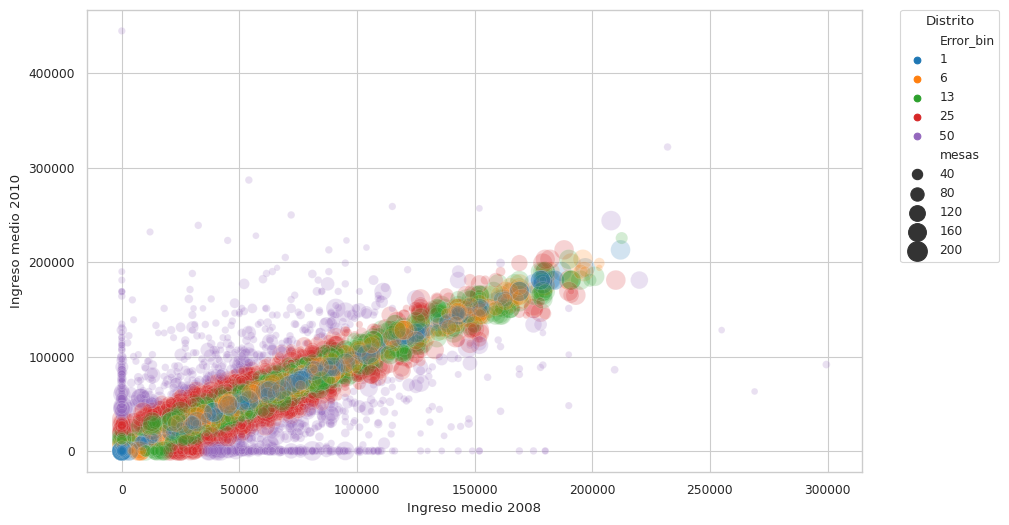

In [328]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style and color palette
sns.set_style('whitegrid')
sns.set_context('paper')
palette = sns.color_palette('tab10')

# Set figure size
fig, ax = plt.subplots(figsize=(10, 6))

# Plot data
sns.scatterplot(
    data=circuitos,
    x='ingresos_08',
    y='ingresos_10',
    hue='Error_bin',
    palette=palette,
    size=circuitos['mesas'].apply(lambda x: min(x / max(circuitos['mesas']) * 5000, 200)),
    sizes=(20, 200),
    alpha=0.2,
    ax=ax
)

# Set axis labels
ax.set_xlabel('Ingreso medio 2008')
ax.set_ylabel('Ingreso medio 2010')

# Set legend
ax.legend(
    title='Distrito',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)

plt.show()


/tmp/ipykernel_24433/3172943110.py:18: UserWarning: 
The palette list has fewer values (10) than needed (24) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


ValueError: s must be a scalar, or float array-like with the same size as x and y

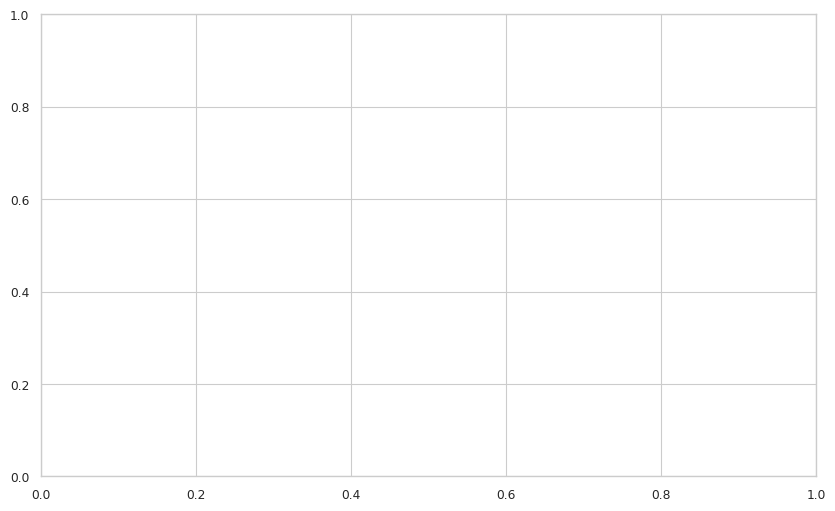

In [329]:


## Make a fancy plot
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Set style
sns.set_style('whitegrid')
sns.set_context('paper')

# Set color palette
# palette = sns.color_palette('colorblind')
palette = sns.color_palette('tab10')

# Set figure size
fig, ax = plt.subplots(figsize=(10, 6))

# Plot data
sns.scatterplot(
    data=ingreso_medio,
    x='ingresos_08',
    y='ingresos_10',
    hue='distrito_id',
    palette=palette,
    s='mesas',
    alpha=0.2,
    ax=ax
)

# Set axis labels
ax.set_xlabel('Ingreso medio 2008'); ax.set_ylabel('Ingreso medio 2010')

# Set legend
ax.legend(
    title='Distrito',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)

# fig.savefig('./ingreso_medio_2008_vs_2010.png', dpi=300, bbox_inches='tight')
plt.show()


### Tamanos de circuitos

In [160]:
votos = data_circ_table_cnt['GRAL23n']['PR'].sum().sort_values(ascending = False)
votos

votos_tipo  agrupacion_nombre_                              agrupacion_nombre                             
POSITIVO    Union Por La Patria                             Union Por La Patria                               9645983.0
            La Libertad Avanza                              La Libertad Avanza                                7884336.0
            Juntos Por El Cambio                            Juntos Por El Cambio                              6267152.0
            Hacemos Por Nuestro Pais                        Hacemos Por Nuestro Pais                          1784315.0
            Frente De Izquierda Y De Trabajadores - Unidad  Frente De Izquierda Y De Trabajadores - Unidad     709932.0
BLANCO      000000                                          000000                                             554161.0
NULO        000000                                          000000                                             224864.0
COMANDO     000000                                   

In [163]:
100*(4e5/votos.sum())

1.4759779968580118

In [95]:
votos = data_circ_table_cnt['PASO23n']['PR'].sum().sort_values(ascending = False)
votos

votos_tipo  agrupacion_nombre_                              agrupacion_nombre                             
POSITIVO    La Libertad Avanza                              La Libertad Avanza                                7116352.0
            Juntos Por El Cambio                            Juntos Por El Cambio                              6698029.0
            Union Por La Patria                             Union Por La Patria                               6460689.0
BLANCO      000000                                          000000                                            1148342.0
POSITIVO    Hacemos Por Nuestro Pais                        Hacemos Por Nuestro Pais                           907437.0
            Frente De Izquierda Y De Trabajadores - Unidad  Frente De Izquierda Y De Trabajadores - Unidad     628893.0
NULO        000000                                          000000                                             293041.0
POSITIVO    Principios Y Valores                     

<Axes: >

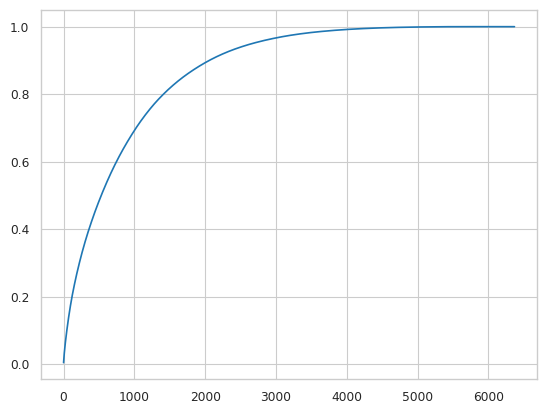

In [98]:
votos_circuito = data_circ_table_cnt['GRAL23n']['PR'].sum(1).sort_values(ascending=False)

s = votos_circuito.reset_index(drop = True)
(s/s.sum()).cumsum().plot(grid = True)

In [99]:
votos_circuito.sum()/circuitos.electores.sum()

0.09812352768816042

In [104]:
## Tomar los 3000 circuitos grandes, es decir, los que tienen mas de 1000 votos.
votos_circuito.head(2100)

distrito_id  seccion_id  circuito_id
2            77          00652A         109046.0
             61          00635B          88011.0
             38          000302          83658.0
             80          000665          81368.0
             61          000635          80902.0
                                          ...   
18           7           000063           2929.0
6            1           000017           2920.0
23           2           000028           2919.0
13           16          000117           2918.0
6            13          000091           2918.0
Length: 2100, dtype: float64

In [105]:
circuitos_ppales = votos_circuito.loc[votos_circuito > 2000]
circuitos_ppales = circuitos_ppales.index.to_frame().reset_index(drop=True)

### Tamanos de listas

In [924]:
votos_lista = data_circ.loc[data_circ.cargo_id == 1].groupby(['eleccion_id', 'votos_tipo', 'agrupacion_nombre_', 'agrupacion_nombre'])['votos_cantidad'].sum()
votos_lista = votos_lista.sort_values(ascending=False)
main_listas  = votos_lista.head(14)
# s = votos_lista.reset_index(drop = True)
# (s/s.sum()).cumsum().plot(grid = True)
# (s/s.sum()).cumsum()

In [925]:
main_listas

eleccion_id  votos_tipo  agrupacion_nombre_                              agrupacion_nombre                             
7            POSITIVO    Union Por La Patria                             Union Por La Patria                               9645983
                         La Libertad Avanza                              La Libertad Avanza                                7884336
8            POSITIVO    La Libertad Avanza                              La Libertad Avanza                                7116352
                         Juntos Por El Cambio                            Juntos Por El Cambio                              6698029
                         Union Por La Patria                             Union Por La Patria                               6460689
7            POSITIVO    Juntos Por El Cambio                            Juntos Por El Cambio                              6267152
                         Hacemos Por Nuestro Pais                        Hacemos Por Nuestro P

In [926]:
# main_listas = info_table['votos_cantidad'].sum().sort_values(ascending=False).head(10)
main_listas = main_listas.index.to_frame().reset_index(drop=True)
main_listas


,eleccion_id,votos_tipo,agrupacion_nombre_,agrupacion_nombre
0,7,POSITIVO,Union Por La Patria,Union Por La Patria
1,7,POSITIVO,La Libertad Avanza,La Libertad Avanza
2,8,POSITIVO,La Libertad Avanza,La Libertad Avanza
3,8,POSITIVO,Juntos Por El Cambio,Juntos Por El Cambio
4,8,POSITIVO,Union Por La Patria,Union Por La Patria
5,7,POSITIVO,Juntos Por El Cambio,Juntos Por El Cambio
6,7,POSITIVO,Hacemos Por Nuestro Pais,Hacemos Por Nuestro Pais
7,8,BLANCO,000000,000000
8,8,POSITIVO,Hacemos Por Nuestro Pais,Hacemos Por Nuestro Pais
9,7,POSITIVO,Frente De Izquierda Y De Trabajadores - Unidad,Frente De Izquierda Y De Trabajadores - Unidad


# Votos Por Circuitos

## Introducción y Preparación de Datos

En este análisis, estamos interesados en explorar los datos electorales a nivel de circuito, integrando información demográfica y geográfica para obtener una comprensión más completa de los patrones de votación. Comenzamos cargando y preparando los conjuntos de datos necesarios, incluyendo los ingresos medianos por circuito, las mesas electorales, y la información geográfica de los departamentos y regiones.

Realizamos agregaciones y fusiones para crear un conjunto de datos de circuitos, que incluye el número de electores, el número de mesas, y los ingresos medianos. También integramos nombres de provincias y regiones para enriquecer nuestro análisis.


In [774]:
# Aggregation and merging
print("Aggregating data...")
ingreso_medio = (persona_circuito.groupby(['distrito_id', 'seccion_id', 'seccion_nombre', 'circuito'])
                 .agg({'ingresos': 'median'}).reset_index()
                 .assign(circuito_id=lambda df: df['circuito'].astype(str).str.zfill(6))
                 .drop('circuito', axis=1))
ingreso_medio[['distrito_id', 'seccion_id']] = ingreso_medio[['distrito_id', 'seccion_id']].astype('int64')

circuitos = (mesas.groupby(['eleccion_id', 'distrito_id', 'seccion_id', 'circuito_id']).mesa_electores
             .agg(['sum', 'count']).reset_index()
             .rename(columns={'sum': 'electores', 'count': 'mesas'})
             .merge(ingreso_medio, on=['distrito_id', 'seccion_id', 'circuito_id'], how='left'))

prov_nams = pd.read_csv(f'{BD_path}/distrito_table.csv')
radio_region = pd.read_csv('./../datos/info/radio_ref.csv', usecols=['radio', 'NOMDPTO', 'Region'])
radios_circuitos_secciones = pd.read_csv('./../datos/info/radios_circuitos_secciones_ref.csv')[['COD_2010', 'distrito_id', 'seccion_id', 'seccion_nombre']]

merge = radios_circuitos_secciones.merge(radio_region.assign(COD_2010=radio_region['radio'].astype(str).str.zfill(9)), on='COD_2010', how='left')
seccion_region = (merge.drop(['COD_2010', 'radio'], axis=1).drop_duplicates()
                  .groupby(['distrito_id', 'seccion_id', 'seccion_nombre']).first().reset_index())
print("Done!")


Aggregating data...
Done!


In [464]:
circuitos.groupby(['eleccion_id'])['electores'].sum()

eleccion_id
0    31820939
1    31754774
2    32474342
3    25411936
4    33510619
5    30350488
6    34084310
7    36846765
8    36354517
Name: electores, dtype: int64

## Verificación de Datos

Antes de proceder con el análisis, es crucial verificar que los datos se hayan cargado y fusionado correctamente. Chequeamos los totales de electores y votos para los cargos de presidente y diputados nacionales en las elecciones PASO y generales de 2023.

Esto nos ayuda a asegurar la integridad de nuestros datos y a identificar cualquier posible incongruencia antes de avanzar.


In [775]:
# Data verification
print("Total electores in circuitos:", circuitos['electores'].sum())
print("Total votos in data_circ:", data_circ.groupby(['eleccion_id', 'cargo_id'])['votos_cantidad'].sum())


Total electores in circuitos: 292608690
Total votos in data_circ: eleccion_id  cargo_id
7            1           27100675
             3           26820148
8            1           24016776
             3           23502142
Name: votos_cantidad, dtype: int64


## Análisis de Datos y Creación de Bins

Realizamos un análisis exploratorio de los datos para entender mejor la distribución de los votos y las características de los circuitos. Además, creamos bins de electores para facilitar análisis posteriores y visualizaciones.

También calculamos la fracción de votos que permanecen en el conjunto de datos después de descartar los circuitos pequeños, lo que nos proporciona una medida de cuánto impacta este filtrado en nuestro análisis.


In [916]:
# Further merging and data preparation
merged_data = (circuitos.merge(data_circ, left_on=['eleccion_id', 'distrito_id', 'seccion_id', 'circuito_id'], 
                               right_on=['eleccion_id', 'distrito_id', 'seccion_id', 'circuito_id'], how='right')
               .merge(prov_nams, on='distrito_id')
               .merge(seccion_region, on=['distrito_id', 'seccion_id', 'seccion_nombre'], how='left')).rename(columns={'electores': 'electores_circuito'})


In [917]:
print("Total votos in merged_data:", merged_data.groupby(['eleccion_id', 'cargo_id'])['votos_cantidad'].sum())


Total votos in merged_data: eleccion_id  cargo_id
7            1           27100675
             3           26820148
8            1           24016776
             3           23502142
Name: votos_cantidad, dtype: int64


## Cálculo del Peso de circuitos en Votos

A continuación, calculamos y mostramos la fracción de votos que permanecen en el conjunto de datos `info` después de descartar los circuitos pequeños. Esto nos ayuda a evaluar el impacto de este filtrado en los resultados de nuestro análisis.


In [918]:

info = merged_data.query("electores_circuito > 3000")

total_votos = merged_data.votos_cantidad.sum()
votos_en_info = info.votos_cantidad.sum()
fraccion_votos = votos_en_info / total_votos
print(f"Fracción de votos en circuitos con más de 2500 electores: {fraccion_votos:.2%}")


Fracción de votos en circuitos con más de 2500 electores: 92.71%


In [919]:
info.head()

,eleccion_id,distrito_id,seccion_id,circuito_id,electores_circuito,mesas,seccion_nombre,ingresos,cum_pct_by_electors,cum_pct_by_income,...,eleccion_tipo,recuento_tipo,padron_tipo,eleccion_tag,cargo_nombre,cargo_tag,votos_porcentaje,distrito_nombre,NOMDPTO,Region
0,7,1,1,000001,12230,36,Comuna 01,299000.0,0.667970,0.924397,...,GENERAL,PROVISORIO,NORMAL,GRAL23n,Presidente,PR,1.0,Ciudad Autónoma De Buenos Aires,Comuna 01,Gran Buenos Aires
1,7,1,1,000002,12479,37,Comuna 01,279000.0,0.660155,0.908125,...,GENERAL,PROVISORIO,NORMAL,GRAL23n,Presidente,PR,1.0,Ciudad Autónoma De Buenos Aires,Comuna 01,Gran Buenos Aires
2,7,1,1,000003,3378,10,Comuna 01,295500.0,0.909438,0.917247,...,GENERAL,PROVISORIO,NORMAL,GRAL23n,Presidente,PR,1.0,Ciudad Autónoma De Buenos Aires,Comuna 01,Gran Buenos Aires
4,7,1,1,000005,26190,75,Comuna 01,127000.0,0.361332,0.133260,...,GENERAL,PROVISORIO,NORMAL,GRAL23n,Presidente,PR,1.0,Ciudad Autónoma De Buenos Aires,Comuna 01,Gran Buenos Aires
5,7,1,1,000006,21552,63,Comuna 01,299000.0,0.441767,0.924960,...,GENERAL,PROVISORIO,NORMAL,GRAL23n,Presidente,PR,1.0,Ciudad Autónoma De Buenos Aires,Comuna 01,Gran Buenos Aires


In [920]:
info.columns

Index(['eleccion_id', 'distrito_id', 'seccion_id', 'circuito_id',
       'electores_circuito', 'mesas', 'seccion_nombre', 'ingresos',
       'cum_pct_by_electors', 'cum_pct_by_income', 'cargo_id',
       'agrupacion_nombre_', 'agrupacion_nombre', 'votos_tipo',
       'votos_cantidad', 'año', 'eleccion_tipo', 'recuento_tipo',
       'padron_tipo', 'eleccion_tag', 'cargo_nombre', 'cargo_tag',
       'votos_porcentaje', 'distrito_nombre', 'NOMDPTO', 'Region'],
      dtype='object')

In [781]:
# info_columns = set(info.columns)
# votos_EPH_circuitos_columns = set(votos_EPH_circuitos.columns)
# data_reset_index_columns = set(data.reset_index().columns)

# print("Columns in 'info' but not in 'votos_EPH_circuitos':", info_columns - votos_EPH_circuitos_columns)
# print("Columns in 'votos_EPH_circuitos' but not in 'info':", votos_EPH_circuitos_columns - info_columns)
# print("Columns in 'info' but not in 'data.reset_index()':", info_columns - data_reset_index_columns)
# print("Columns in 'data.reset_index()' but not in 'info':", data_reset_index_columns - info_columns)
# print("Columns in 'votos_EPH_circuitos' but not in 'data.reset_index()':", votos_EPH_circuitos_columns - data_reset_index_columns)
# print("Columns in 'data.reset_index()' but not in 'votos_EPH_circuitos':", data_reset_index_columns - votos_EPH_circuitos_columns)


In [782]:
# Data analysis and binning
print("Total votos in merged_data:", merged_data.groupby(['eleccion_id', 'cargo_id'])['votos_cantidad'].sum())
print("Total votos in info:", info.groupby(['eleccion_id', 'cargo_id'])['votos_cantidad'].sum())
print("Unique values in info:", info.nunique())

# merged_data['elector_bin'] = pd.cut(merged_data['electores_circuito'], bins=10, labels=False)


Total votos in merged_data: eleccion_id  cargo_id
7            1           27100675
             3           26820148
8            1           24016776
             3           23502142
Name: votos_cantidad, dtype: int64
Total votos in info: eleccion_id  cargo_id
7            1           25109238
             3           24864886
8            1           22262068
             3           21811144
Name: votos_cantidad, dtype: int64
Unique values in info: eleccion_id               2
distrito_id              24
seccion_id              133
circuito_id            1257
electores_circuito     4087
mesas                   182
seccion_nombre          377
ingresos                124
cargo_id                  2
agrupacion_nombre_       11
agrupacion_nombre        99
votos_tipo                6
votos_cantidad         7956
año                       1
eleccion_tipo             2
recuento_tipo             1
padron_tipo               1
eleccion_tag              2
cargo_nombre              2
cargo_tag 

In [651]:

# Agrupar por eleccion_id, cargo_id, distrito_id, seccion_id, circuito_id, votos_tipo, AGRUPACION_NOMBRE_ (es decir, 'Resto' para listas chicas)
df = info.groupby(['eleccion_id', 'eleccion_tag', 'cargo_id', 'cargo_tag', 'distrito_id', 'distrito_nombre', 'seccion_id', 'seccion_nombre', 'NOMDPTO', 'circuito_id', 'votos_tipo', 'agrupacion_nombre_']
                         )[['votos_cantidad', 'votos_porcentaje']].sum().unstack(['eleccion_id', 'eleccion_tag'])

# # Calcular las diferencias
diffc = df['votos_cantidad'].diff(-1, axis=1).dropna(axis = 1, how = 'all')
diffp = df['votos_porcentaje'].diff(-1, axis=1).dropna(axis = 1, how = 'all')

# Add the additional level to the diff DataFrames
diffc.columns = pd.MultiIndex.from_product([['cantidad_diff'], diffc.columns.get_level_values(0), diffc.columns.get_level_values(1)], names=[None, 'eleccion_id', 'eleccion_tag'])
diffp.columns = pd.MultiIndex.from_product([['porcentaje_diff'], diffp.columns.get_level_values(0), diffp.columns.get_level_values(1)], names=[None, 'eleccion_id', 'eleccion_tag'])
diff = pd.concat([diffc, diffp], axis=1)


diff_ = diff.stack(['eleccion_id', 'eleccion_tag'])
df_ = df.stack(['eleccion_id', 'eleccion_tag'])

data = pd.concat([df_, diff_], axis = 1)

In [652]:
data.head()


votos_cantidad  \
cargo_id cargo_tag distrito_id distrito_nombre                 seccion_id seccion_nombre NOMDPTO   circuito_id votos_tipo agrupacion_nombre_ eleccion_id eleccion_tag                   
1        PR        1           Ciudad Autónoma De Buenos Aires 1          Comuna 01      Comuna 01 000001      BLANCO     000000             7           GRAL23n                145.0   
                                                                                                                                             8           PASO23n                103.0   
                                                                                                               COMANDO    000000             7           GRAL23n                  9.0   
                                                                                                                                             8           PASO23n                  0.0   
                                                                                                               IMPUGNADO  000000             7           GRAL23n                  0.0   

                                                                                                                                                                       votos_porcentaje  \
cargo_id cargo_tag distrito_id distrito_nombre                 seccion_id seccion_nombre NOMDPTO   circuito_id votos_tipo agrupacion_nombre_ eleccion_id eleccion_tag                     
1        PR        1           Ciudad Autónoma De Buenos Aires 1          Comuna 01      Comuna 01 000001      BLANCO     000000             7           GRAL23n                    1.0   
                                                                                                                                             8           PASO23n                    1.0   
                                                                                                               COMANDO    000000             7           GRAL23n                    1.0   
                                                                                                                                             8           PASO23n                    0.0   
                                                                                                               IMPUGNADO  000000             7           GRAL23n                    0.0   

                                                                                                                                                                       cantidad_diff  \
cargo_id cargo_tag distrito_id distrito_nombre                 seccion_id seccion_nombre NOMDPTO   circuito_id votos_tipo agrupacion_nombre_ eleccion_id eleccion_tag                  
1        PR        1           Ciudad Autónoma De Buenos Aires 1          Comuna 01      Comuna 01 000001      BLANCO     000000             7           GRAL23n                42.0   
                                                                                                                                             8           PASO23n                 NaN   
                                                                                                               COMANDO    000000             7           GRAL23n                 9.0   
                                                                                                                                             8           PASO23n                 NaN   
                                                                                                               IMPUGNADO  000000             7           GRAL23n                 0.0   

                                                                                                                                                                       porcentaje_diff  
cargo_id cargo_tag distrito_id distrito_nombre                 seccion_id seccion_nombr

In [ ]:
## Graficos differencia por caracteristicas del circuito

In [783]:
circuitos['cum_pct_by_electors'] = circuitos.sort_values('electores', ascending = False)['electores'].cumsum() / circuitos['electores'].sum()
circuitos['cum_pct_by_income'] = circuitos.sort_values('ingresos', ascending = True)['electores'].cumsum() / circuitos['electores'].sum()

circuitos.head()


,eleccion_id,distrito_id,seccion_id,circuito_id,electores,mesas,seccion_nombre,ingresos,cum_pct_by_electors,cum_pct_by_income
0,0,1,1,000001,10641,31,Comuna 01,299000.0,0.712011,0.919828
1,0,1,1,000002,10073,29,Comuna 01,279000.0,0.724999,0.906563
2,0,1,1,000003,1949,6,Comuna 01,295500.0,0.949551,0.917264
3,0,1,1,000004,2027,6,Comuna 01,306000.0,0.946886,0.925215
4,0,1,1,000005,7788,23,Comuna 01,127000.0,0.784792,0.133820


In [786]:
votos_EPH_circuitos = data.reset_index().merge(circuitos)
votos_EPH_circuitos = votos_EPH_circuitos.merge(seccion_AGLO)

check = votos_EPH_circuitos.groupby(['eleccion_id', 'eleccion_tag', 'cargo_id', 'cargo_tag'])['votos_cantidad'].sum()
check

eleccion_id  eleccion_tag  cargo_id  cargo_tag
7            GRAL23n       1         PR           21969571.0
                           3         DN           21743548.0
8            PASO23n       1         PR           19428804.0
                           3         DN           19025179.0
Name: votos_cantidad, dtype: float64

In [785]:
votos_EPH_circuitos.head()

,cargo_id,cargo_tag,distrito_id,distrito_nombre,seccion_id,seccion_nombre,NOMDPTO,circuito_id,votos_tipo,agrupacion_nombre_,...,eleccion_tag,votos_cantidad,votos_porcentaje,cantidad_diff,porcentaje_diff,electores,mesas,ingresos,cum_pct_by_electors,cum_pct_by_income
0,1,PR,1,Ciudad Autónoma De Buenos Aires,1,Comuna 01,Comuna 01,000001,BLANCO,000000,...,GRAL23n,145.0,1.000000,42.0,0.000000,12230,36,299000.0,0.66797,0.924397
1,1,PR,1,Ciudad Autónoma De Buenos Aires,1,Comuna 01,Comuna 01,000001,COMANDO,000000,...,GRAL23n,9.0,1.000000,9.0,1.000000,12230,36,299000.0,0.66797,0.924397
2,1,PR,1,Ciudad Autónoma De Buenos Aires,1,Comuna 01,Comuna 01,000001,IMPUGNADO,000000,...,GRAL23n,0.0,0.000000,0.0,0.000000,12230,36,299000.0,0.66797,0.924397
3,1,PR,1,Ciudad Autónoma De Buenos Aires,1,Comuna 01,Comuna 01,000001,NULO,000000,...,GRAL23n,54.0,1.000000,-11.0,0.000000,12230,36,299000.0,0.66797,0.924397
4,1,PR,1,Ciudad Autónoma De Buenos Aires,1,Comuna 01,Comuna 01,000001,POSITIVO,Frente De Izquierda Y De Trabajadores - Unidad,...,GRAL23n,342.0,0.048614,-67.0,-0.014945,12230,36,299000.0,0.66797,0.924397


In [787]:
votos_EPH_circuitos.eleccion_tag.value_counts()

eleccion_tag
PASO23n    45970
GRAL23n    33970
Name: count, dtype: int64

In [683]:
# Checks
# votos_EPH_circuitos.groupby(pd.cut(votos_EPH_circuitos.cum_pct_by_electors, 10)).size()
# votos_EPH_circuitos.groupby(pd.cut(votos_EPH_circuitos.cum_pct_by_electors, 10)).votos_cantidad.sum()


# votos_EPH_circuitos.groupby(pd.cut(votos_EPH_circuitos.cum_pct_by_income, 10)).size()
# votos_EPH_circuitos.groupby(pd.cut(votos_EPH_circuitos.cum_pct_by_income, 8)).votos_cantidad.sum()

In [719]:
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

# Set the theme of the plot and font settings
sns.set_style('whitegrid')  # Set style
sns.set_context('notebook', font_scale=0.8)  # Set context and adjust font size
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5

# Function to lighten colors
def lighten_color(hex_color, factor=0.5):
    """Lighten a color by a given factor."""
    # Convert hex to RGB
    hex_color = hex_color.lstrip('#')
    rgb = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    
    # Calculate the new color
    new_rgb = tuple(int(c + (255 - c) * factor) for c in rgb)
    
    # Convert RGB back to hex
    new_hex = '#{:02x}{:02x}{:02x}'.format(*new_rgb)
    return new_hex

# Define the color palette
colors_dict = {
    'La Libertad Avanza': '#c63667',
    'Union Por La Patria': '#1175a9',
    'Juntos Por El Cambio': '#e1ce26'
}

# Create lighter shades for PASO results
colors_dict_light = {party: lighten_color(color) for party, color in colors_dict.items()}

# Combine colors for both elections
election_colors = {f'{party} - GRAL23n': colors_dict[party] for party in colors_dict}
election_colors.update({f'{party} - PASO23n': colors_dict_light[party] for party in colors_dict_light})


In [933]:

# Filter data for election 7, cargo 1
# data_filtered = votos_EPH_circuitos[(votos_EPH_circuitos['eleccion_id'] == 7) & (votos_EPH_circuitos['cargo_id'] == 1)].copy()
data_all = votos_EPH_circuitos[(votos_EPH_circuitos['cargo_id'] == 1)].copy()

# Create bins for cum_pct_by_income
bins = np.linspace(0, 1, 21)
data_all['income_bin'] = pd.cut(data_all['cum_pct_by_income'], bins, labels=False)

# Filter for the main parties and elections of interest
agrupacion_nombre = ['Union Por La Patria', 'La Libertad Avanza', 'Juntos Por El Cambio']
elections_of_interest = ['GRAL23n', 'PASO23n']
data_all = data_all[(data_all['agrupacion_nombre_'].isin(agrupacion_nombre)) & (data_all['eleccion_tag'].isin(elections_of_interest))]



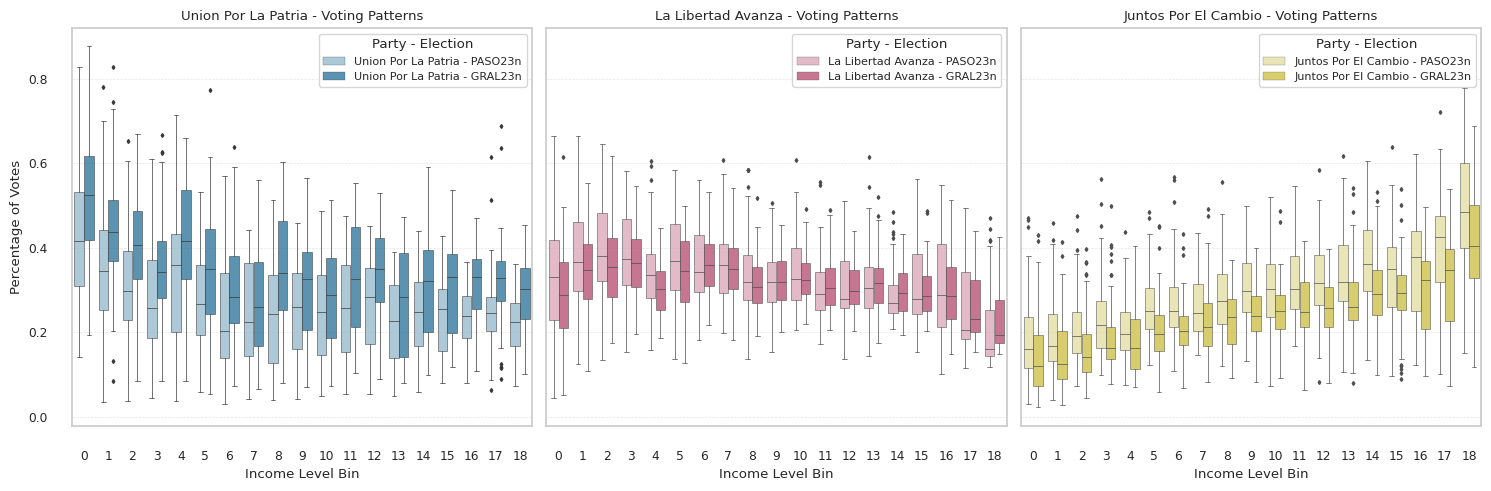

In [934]:

# Create subplots
fig, axs = plt.subplots(1, len(agrupacion_nombre), figsize=(15, 5), sharey=True)

# Loop over main parties and create boxplots
for i, party in enumerate(agrupacion_nombre):
    data_filtered = data_all[(data_all['agrupacion_nombre_'] == party)]
    
    # Create the combined party - election tag for hue
    data_filtered['party_election'] = data_filtered['agrupacion_nombre_'] + ' - ' + data_filtered['eleccion_tag']
    
    # Set the order of the series
    hue_order = sorted(data_filtered['party_election'].unique(), key=lambda x: ('GRAL' in x, x))
    
    # Create boxplot for votos_porcentaje
    ax = sns.boxplot(x='income_bin', y='votos_porcentaje', hue='party_election', data=data_filtered,
                     palette=election_colors, linewidth=0.5, whis=1.5, fliersize=2, ax=axs[i],
                     hue_order=hue_order)
    ax.set_title(f'{party} - Voting Patterns')
    ax.set_xlabel('Income Level Bin')
    if i == 0:
        ax.set_ylabel('Percentage of Votes')
    else:
        ax.set_ylabel('')

    # ax = sns.boxplot(x='income_bin', y='porcentaje_diff', hue='party_election', data=data_filtered,
    #             palette=election_colors, linewidth=0.5, whis=1.5, fliersize=2, ax=axs[i],
    #              hue_order=hue_order)
    # ax.set_title('Voting Patterns Across Income Levels (Percentage Difference)')
    # ax.set_xlabel('Income Level Bin')
    # ax.set_ylabel('Percentage Difference')
    
    # Manually set alpha for box patches
    for patch in ax.patches:
        patch.set_alpha(0.75)

    # Set legend
    ax.legend(title='Party - Election', fontsize='small')

plt.tight_layout()
plt.show()

In [938]:

# Filter data for election 7, cargo 1
# data_filtered = votos_EPH_circuitos[(votos_EPH_circuitos['eleccion_id'] == 7) & (votos_EPH_circuitos['cargo_id'] == 1)].copy()
data_all = votos_EPH_circuitos[(votos_EPH_circuitos['cargo_id'] == 1)].copy()

# Create bins for cum_pct_by_income
bins = np.linspace(0, 1, 11)
data_all['income_bin'] = pd.cut(data_all['cum_pct_by_income'], bins, labels=False)

# Filter for the main parties and elections of interest
agrupacion_nombre = ['Union Por La Patria', 'La Libertad Avanza', 'Juntos Por El Cambio']
elections_of_interest = ['GRAL23n', 'PASO23n']
data_all = data_all[(data_all['agrupacion_nombre_'].isin(agrupacion_nombre)) & (data_all['eleccion_tag'].isin(elections_of_interest))]



In [823]:
# agrupacion_nombre

# data_filtered = data_all[(data_all['agrupacion_nombre_'] == 'Juntos Por El Cambio') & (data_all['AGLOMERADO'] == 33)]

# # Create the combined party - election tag for hue
# data_filtered['party_election'] = data_filtered['agrupacion_nombre_'] + ' - ' + data_filtered['eleccion_tag']

# # Set the order of the series
# hue_order = sorted(data_filtered['party_election'].unique(), key=lambda x: ('GRAL' in x, x))



# # Create boxplot with modifications for votos_porcentaje
# plt.figure(figsize=(10, 6))
# ax = sns.boxplot(x='income_bin', y='votos_porcentaje', hue='party_election', data=data_filtered,
#                  palette=election_colors, linewidth=0.5, whis=1.5, fliersize=2,
#                  hue_order=hue_order)
# ax.set_title('Voting Patterns Across Income Levels (Percentage of Votes)')
# ax.set_xlabel('Income Level Bin')
# ax.set_ylabel('Percentage of Votes')

# # Manually set alpha for box patches
# for patch in ax.patches:
#     patch.set_alpha(0.75)

# # Set legend
# plt.legend(title='Party - Election', fontsize='small')
# plt.show()



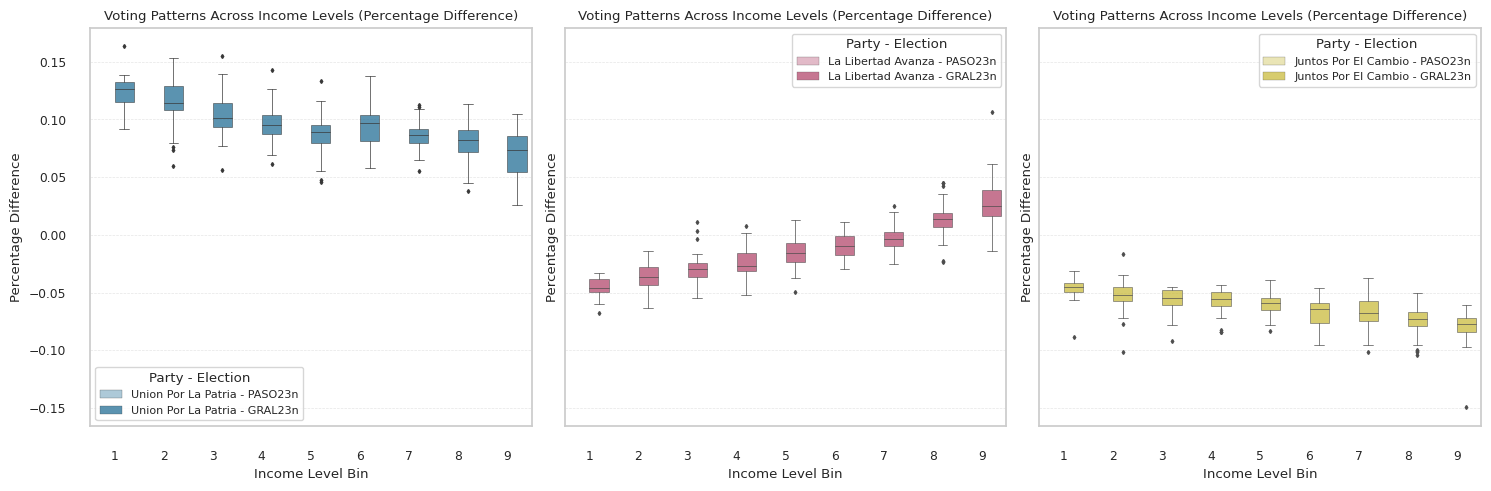

In [939]:

# Create subplots
fig, axs = plt.subplots(1, len(agrupacion_nombre), figsize=(15, 5), sharey=True)

# Loop over main parties and create boxplots
for i, party in enumerate(agrupacion_nombre):
    data_filtered = data_all[(data_all['agrupacion_nombre_'] == party) & (data_all['AGLOMERADO'].isin([32, 33]))]
    
    # Create the combined party - election tag for hue
    data_filtered['party_election'] = data_filtered['agrupacion_nombre_'] + ' - ' + data_filtered['eleccion_tag']
    
    # Set the order of the series
    hue_order = sorted(data_filtered['party_election'].unique(), key=lambda x: ('GRAL' in x, x))


    ax = sns.boxplot(x='income_bin', y='porcentaje_diff', hue='party_election', data=data_filtered,
                palette=election_colors, linewidth=0.5, whis=1.5, fliersize=2, ax=axs[i],
                 hue_order=hue_order)
    ax.set_title('Voting Patterns Across Income Levels (Percentage Difference)')
    ax.set_xlabel('Income Level Bin')
    ax.set_ylabel('Percentage Difference')
    
    # Manually set alpha for box patches
    for patch in ax.patches:
        patch.set_alpha(0.75)

    # Set legend
    ax.legend(title='Party - Election', fontsize='small')

plt.tight_layout()
plt.show()

In [864]:
import warnings
warnings.filterwarnings('ignore')

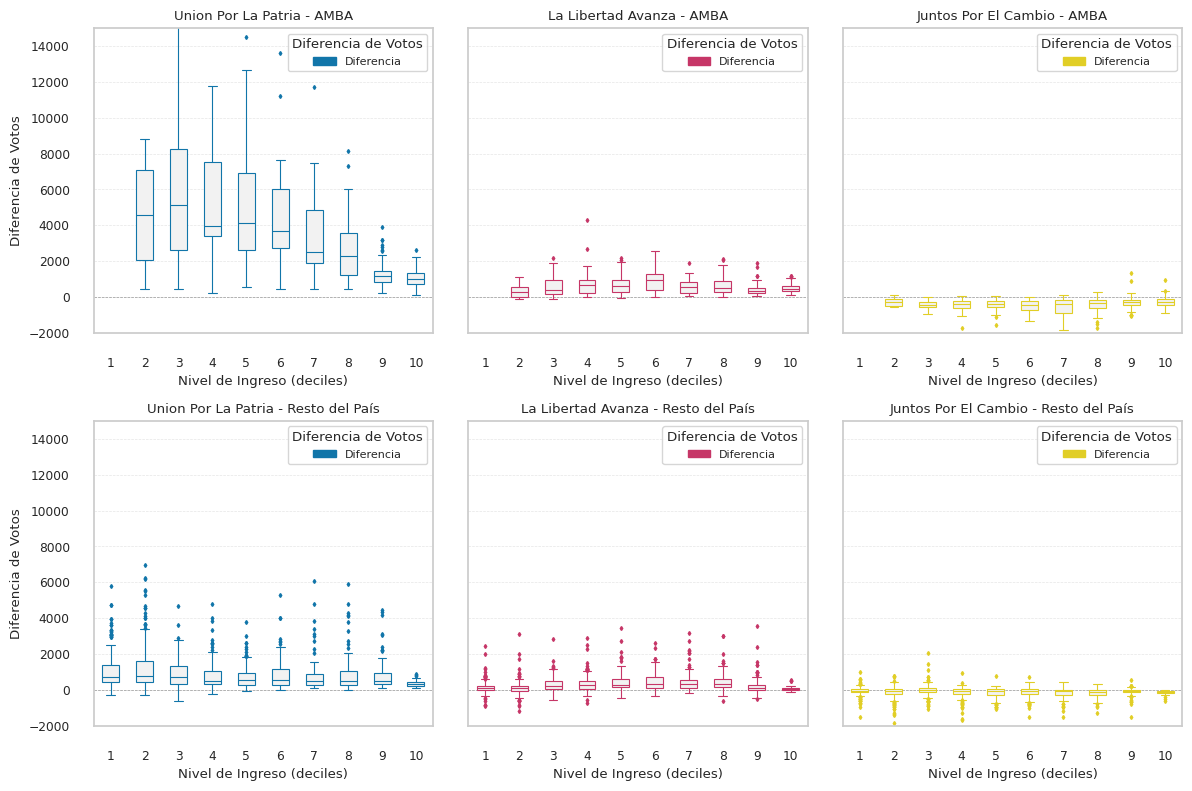

In [944]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define the color mapping
party_colors = {
    'La Libertad Avanza': '#c63667',
    'Union Por La Patria': '#1175a9',
    'Juntos Por El Cambio': '#e1ce26'
}

# 1. Create a 2x3 subplot grid
fig, axs = plt.subplots(2, len(agrupacion_nombre), figsize=(12, 8), sharey='row')

# Define the agglomerates sets
agglomerates = [(32, 33), 'others']
data_all['income_bin'] = data_all['income_bin'].astype(int)

# 2. Add a second loop for agglomerate filtering
for row, aglo in enumerate(agglomerates):
    for i, party in enumerate(agrupacion_nombre):
        # 3. Update the data filtering step
        if aglo == 'others':
            data_filtered = data_all[(data_all['agrupacion_nombre_'] == party) & (~data_all['AGLOMERADO'].isin([32, 33]))]
        else:
            data_filtered = data_all[(data_all['agrupacion_nombre_'] == party) & (data_all['AGLOMERADO'].isin(aglo))]


        # Create boxplot for percentage difference
        ax = sns.boxplot(x='income_bin', y='cantidad_diff', color=party_colors[party], 
                         data=data_filtered, ax=axs[row, i], fliersize=2, linewidth=0.8, width = .5)
        
        # Adjust box properties
        for patch in ax.patches:
            patch.set_edgecolor(party_colors[party])
            patch.set_facecolor('.95')
        
        # Adjust error bar properties
        for line in ax.lines:
            line.set_color(party_colors[party])
            line.set_mfc(party_colors[party])
            line.set_mec(party_colors[party])

        # Titles and labels
        region = "AMBA" if aglo != "others" else "Resto del País"
        ax.set_title(f'{party} - {region}')
        ax.set_xlabel('Nivel de Ingreso (deciles)')
        if i == 0:
            ax.set_ylabel('Diferencia de Votos')
        else:
            ax.set_ylabel('')
        
        # Set legend
        patch = mpatches.Patch(color=party_colors[party], label='Diferencia')
        ax.legend(handles=[patch], title='Diferencia de Votos', fontsize='small')

        ax.axhline(0, color='.5', linewidth=0.5, linestyle='--', zorder=-10)
        ax.set_ylim(-2000, 15000)

        # Set x-axis ticks and labels conditionally
        if row == 0:
            ax.set_xlim(-1.5, 8.5)
            ax.set_xticks(range(-1, 9))
            ax.set_xticklabels(map(str, range(1, 11)))

        else:
            ax.set_xlim(-.5, 9.5)
            ax.set_xticks(range(0, 10))
            ax.set_xticklabels(map(str, range(1, 11)))


plt.subplots_adjust(wspace=2.2, hspace=2.3)
plt.tight_layout()
plt.show()


In [828]:
import seaborn as sns
print(sns.__version__)

0.12.2


In [974]:

# # Function to configure the y-axis and title of the axis
# def configure_axis_pct(ax, graph_name, file_info):
#     # Format y-axis to show percentages
#     ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
#     # Set title with dynamic content based on file_info


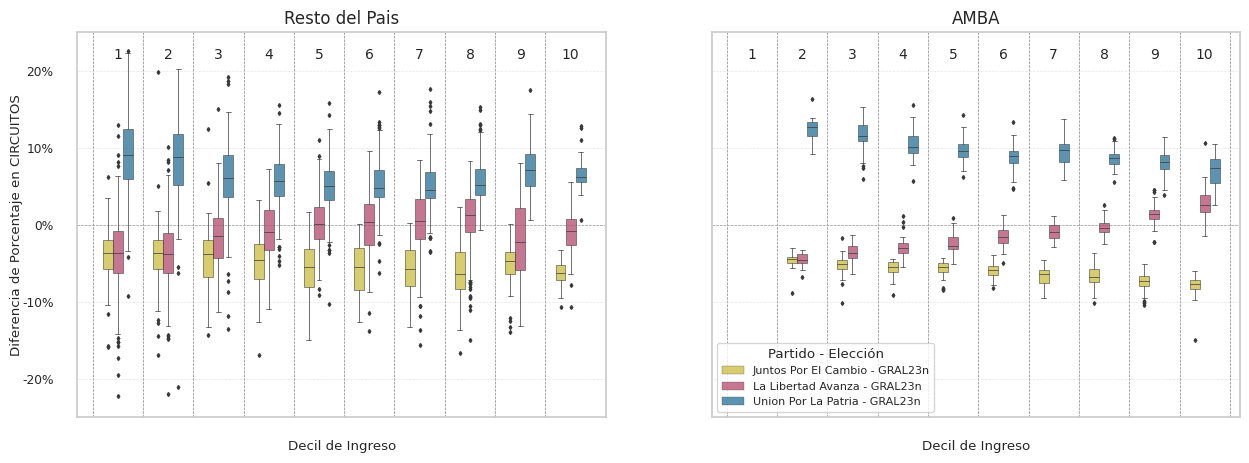

In [1006]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data_all' is your DataFrame and 'agrupacion_nombre' is a list of the parties of interest
agrupacion_nombre = ['Party1', 'Party2']  # Replace with your actual parties

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Define the data subsets
aglomerado_conditions = [(~data_all['AGLOMERADO'].isin([32, 33])), 
                         data_all['AGLOMERADO'].isin([32, 33])]

# Define titles in Spanish
titles = ['Resto del Pais', 
          'AMBA']

# Loop over the conditions and axes to create boxplots
for ax, condition, title in zip(axs, aglomerado_conditions, titles):
    data_filtered = data_all[condition]

    # Create the combined party - election tag for hue
    data_filtered['party_election'] = data_filtered['agrupacion_nombre_'] + ' - ' + data_filtered['eleccion_tag']

    # Sort 'party_election' for consistent hue ordering across plots
    hue_order = sorted(data_filtered['party_election'].unique(), key=lambda x: ('GRAL' in x, x))

    # Create the boxplot
    sns.boxplot(x='income_bin', y='porcentaje_diff', hue='party_election', data=data_filtered,
                 palette=election_colors, linewidth=0.5, whis=1.5, fliersize=2, ax = ax,
                 hue_order=hue_order, width=1.2)

    if ax == axs[1]:
        ax.set_xlim(-1.5, 9)
        ax.set_xticks(range(-1, 9))
        [ax.annotate(f'{i + 1}', xy=(i - .7, .23), xytext=(i - .7, .23), ha='center', va='top', fontsize=10) for i in range(-1, 10)]
        ax.set_xticklabels(map(str, range(1, 11)))
        # y label off
        ax.set_ylabel('')
        # x axis label

    else:
        ax.set_xlim(-.5, 10)
        ax.set_xticks(range(0, 10))
        [ax.annotate(f'{i }', xy=(i - .7, .23), xytext=(i - .7, .23), ha='center', va='top', fontsize=10) for i in range(0, 11)]
        # ax.set_xticklabels(map(str, range(1, 11))) # hide xticklabels
        

        ax.set_ylabel('Diferencia de Porcentaje en CIRCUITOS', va='center', rotation='vertical')

    ax.set_xlabel('Decil de Ingreso', va='center')
    ax.set_xticklabels([])

    # Set the title for the subplot
    ax.set_title(title, fontsize = 12)

    # Set the alpha for the boxes in the plot
    for patch in ax.patches:
        patch.set_alpha(0.75)

    # Modify the y-axis limits if needed
    ax.set_ylim(-0.25, 0.25)
    # hide legend
    ax.legend().set_visible(False)
    ax.axhline(0, color='.5', linewidth=0.5, linestyle='--', zorder=-10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

    [ax.axvline(i - .2, color='.5', linewidth=0.5, linestyle='--', zorder=-10) for i in range(-1, 10)] 

# Set legend
# ax.legend(title='Partido - Elección', fontsize='small')
# Adjust the legend to skip the first three entries
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[3:], labels=labels[3:], title='Partido - Elección', fontsize='small', loc='lower left')


plt.show()


## Seteo de Graficos

In [930]:
# info_plot.sort_values(by='votos_porcentaje', ascending=True).reset_index(drop = True)['votos_cantidad'].cumsum().plot()

# Line2D
from matplotlib.lines import Line2D


def weighted_quantile(values, quantiles, sample_weight=None, values_sorted=False):
    """Compute the weighted quantiles of a 1D numpy array."""
    values = np.array(values)
    quantiles = np.array(quantiles)
    if sample_weight is None:
        sample_weight = np.ones(len(values))
    sample_weight = np.array(sample_weight)
    assert np.all(quantiles >= 0) and np.all(quantiles <= 1), 'quantiles should be in [0, 1]'
    
    if not values_sorted:
        sorter = np.argsort(values)
        values = values[sorter]
        sample_weight = sample_weight[sorter]
    
    weighted_quantiles = np.cumsum(sample_weight) - 0.5 * sample_weight
    weighted_quantiles /= np.sum(sample_weight)
    
    return np.interp(quantiles, weighted_quantiles, values)



import matplotlib.pyplot as plt

def plot_scatter(fig, ax1, info, votos_tipo, agrupacion_nombre_, agrupacion_nombre, ingreso_medio, colors_dict, shade=False, alpha=0.3):
    info_plot = info.loc[(info.votos_tipo == votos_tipo) 
                         & (info['agrupacion_nombre_'] == agrupacion_nombre_) 
                         & (info['agrupacion_nombre'] == agrupacion_nombre)][['distrito_id', 'distrito_nombre', 'circuito_id', 'votos_cantidad', 'votos_porcentaje']]
    info_plot = info_plot.merge(ingreso_medio)

    color = 'gray' if shade else colors_dict.get(agrupacion_nombre_, 'black')

    scatter_plot = ax1.scatter(info_plot['ingresos'], 
               info_plot['votos_porcentaje'] * 100, 
               s=info_plot['votos_cantidad'] / 60,
               color=color,
               alpha=alpha, 
               edgecolors="w", 
               linewidth=0.5)

    ax1.set_xlabel('Ingreso mediano en el CIRCUITO (AR$)')
    ax1.set_ylabel('Votos Porcentaje (%)')
    ax1.set_xlim(50000, 350000)
    ax1.set_ylim(0, 75)
    ax1.set_title(f'Agrupación: {agrupacion_nombre_}', fontsize = 10)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Format the x-axis in engineering notation
    ax1.xaxis.set_major_formatter(lambda x, _: f'{x*1e-3:.0f}k')

    return scatter_plot  # Return scatter plot object for legend


def plot_weighted_box(fig, ax, info, votos_tipo, agrupacion_nombre_, agrupacion_nombre, ingreso_medio, bins=np.arange(10000, 200000, 20000), wbins = False, nweighted=10, max_size = 100):
    info_plot = info.loc[(info.votos_tipo == votos_tipo) 
                         & (info['agrupacion_nombre_'] == agrupacion_nombre_) 
                         & (info['agrupacion_nombre'] == agrupacion_nombre)][['distrito_id', 'distrito_nombre', 'circuito_id', 'votos_cantidad', 'votos_porcentaje']]
    info_plot = info_plot.merge(ingreso_medio)
    info_plot_sorted = info_plot.sort_values(by='votos_porcentaje', ascending=True).reset_index(drop=True)

    if wbins == 'weighted':
        binning = pd.cut(info_plot_sorted.sort_values('ingresos')['votos_cantidad'].cumsum(), nweighted, retbins=True, labels=range(1, nweighted + 1))
        labels, bins = binning[0], binning[1]
        info_plot_sorted['x_bins'] = labels
    else:
        info_plot_sorted['x_bins'] = pd.cut(info_plot_sorted.ingresos, bins=bins, labels=False)

    grouped = info_plot_sorted.groupby('x_bins')
    q1_list, q2_list, q3_list, bin_means = [], [], [], []

    votos_cantidad_list = []
    for bin_num, group in grouped:
        if not group.votos_porcentaje.empty and not group.votos_cantidad.empty:
            q1_val = weighted_quantile(group.votos_porcentaje, 0.25, sample_weight=group.votos_cantidad)
            q2_val = weighted_quantile(group.votos_porcentaje, 0.5, sample_weight=group.votos_cantidad)
            q3_val = weighted_quantile(group.votos_porcentaje, 0.75, sample_weight=group.votos_cantidad)

            q1_list.append(q1_val)
            q2_list.append(q2_val)
            q3_list.append(q3_val)
            bin_means.append(group.ingresos.mean())  # Calculate mean of the bin for x-axis positioning
            votos_cantidad_list.append(group.votos_cantidad.sum())  # Store the sum of votos_cantidad for each group

        else:
            q1_list.append(None)
            q2_list.append(None)
            q3_list.append(None)
            bin_means.append(None)
            votos_cantidad_list.append(None)

    max_votos_cantidad = max(v for v in votos_cantidad_list if v is not None)  # Get the maximum votos_cantidad value
    # print(votos_cantidad_list)
    
    for x, (q1, q2, q3, votos_cantidad) in zip(bin_means, zip(q1_list, q2_list, q3_list, votos_cantidad_list)):
        if q1 is not None and q2 is not None and q3 is not None and votos_cantidad is not None:
            
            q1, q2, q3 = q1*100, q2*100, q3*100  # Convert to percentages
            errbarlw = 1 if wbins == 'weighted' else 1
            ax.plot([x, x], [q1, q3], color='.3', linewidth=errbarlw, alpha = .5)
            ax.plot([x-0.2*10000, x+0.2*10000], [q1, q1], color='.3', linewidth=errbarlw, alpha = .5)
            ax.plot([x-0.2*10000, x+0.2*10000], [q3, q3], color='.3', linewidth=errbarlw, alpha = .5)

            square_size = (votos_cantidad / max_votos_cantidad) * max_size; #print(square_size)
            
            ax.scatter(x, q2, s=square_size, c='w', edgecolors='black', marker='s', alpha=0.5, linewidths=0.5, zorder=10)        

    # We will rely on the scatter plot's X-axis labeling for income
    ax.set_xlabel('Ingreso mediano en el CIRCUITO (AR$)')
    ax.set_ylabel('Votos Porcentaje (%)')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y')
    # Format the x-axis in engineering notation
    ax.xaxis.set_major_formatter(lambda x, _: f'{x*1e-3:.0f}k')


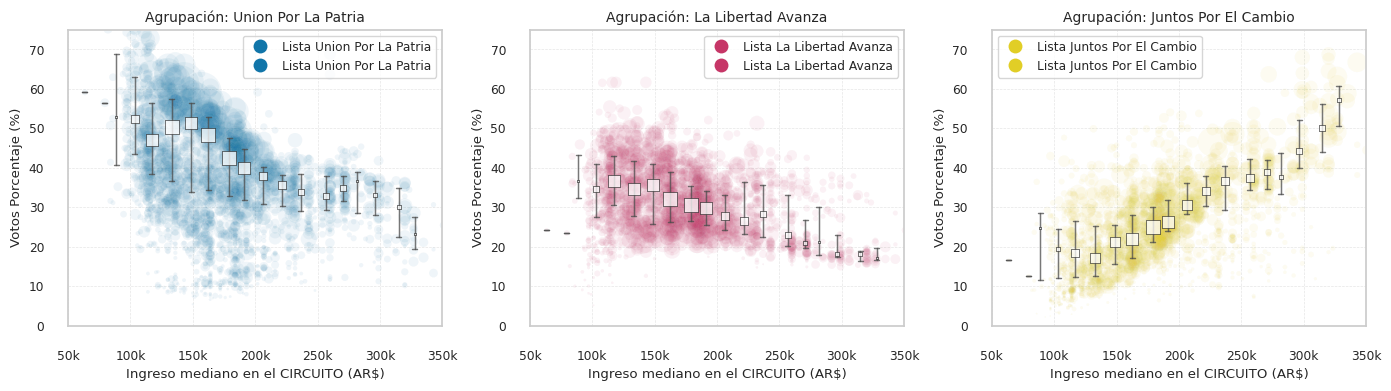

In [932]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import colorsys

# # Adjusting the colors to be more muted
# def adjust_color(color, saturation_scale=0.6, lightness_scale=1.1):
#     r, g, b = [x / 255.0 for x in color]
#     h, l, s = colorsys.rgb_to_hls(r, g, b)
#     s *= saturation_scale
#     l *= lightness_scale
#     r, g, b = colorsys.hls_to_rgb(h, l, s)
#     return (r, g, b)

# colors_dict = {
#     'La Libertad Avanza': adjust_color([255, 0, 255]),  # Adjusted Magenta
#     'Union Por La Patria': adjust_color([0, 255, 255]), # Adjusted Cyan
#     'Juntos Por El Cambio': adjust_color([255, 255, 0]) # Adjusted Yellow
# }

# Define the color mapping
colors_dict = {
    'La Libertad Avanza': '#c63667',
    'Union Por La Patria': '#1175a9',
    'Juntos Por El Cambio': '#e1ce26'
}

# Create a new figure with 1 row and 3 columns for the subplots
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

data_filtered = info.loc[(info.eleccion_id == 7) & (info.cargo_id == 1)]

for ax, agrupacion in zip(axs, main_listas['agrupacion_nombre_'].unique()):
    if agrupacion in colors_dict:
        # Filter rows for the current political force
        rows_for_agrupacion = main_listas[main_listas['agrupacion_nombre_'] == agrupacion]
        
        # Initialize an empty list to collect legend handles and labels
        legend_elements = []  
        
        # Loop through each row in the filtered dataframe
        for _, row in rows_for_agrupacion.iterrows():
            # Plot weighted box
            # plot_weighted_box(fig, ax, info, row['votos_tipo'], agrupacion, row['agrupacion_nombre'], ingreso_medio, bins='weighted', nweighted=10)
            plot_weighted_box(fig, ax, data_filtered, row['votos_tipo'], agrupacion, row['agrupacion_nombre'], ingreso_medio, bins=np.arange(50000, 350000, 15000))
            
            # Plot scatter
            scatter_plot = plot_scatter(fig, ax, data_filtered, row['votos_tipo'], agrupacion, row['agrupacion_nombre'], ingreso_medio, colors_dict, shade=False, alpha=0.03)
            
            # Get color for the current political force
            color = colors_dict.get(agrupacion, 'black')
            
            # Add a legend element for the current political force
            legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f"Lista {row['agrupacion_nombre']}"))

        # Add legend to the current subplot
        ax.legend(handles=legend_elements)

# # Adding a title to the entire plot
# title_font = {'fontweight': 'bold'}
# plt.suptitle('Votos (%) de las agrupaciones en las Generales 2023', fontdict=title_font, y=1.05)

# Showing the plot
plt.tight_layout()
plt.savefig('images/votos_vs_ingresosPASO23.jpg')
plt.show()


In [ ]:
# # Aggregation
# print("Aggregating data...")
# ingreso_medio = persona_circuito.groupby(['distrito_id', 'seccion_id', 'seccion_nombre', 'circuito']).agg({'ingresos': 'median'}).reset_index()
# ingreso_medio['circuito_id'] = ingreso_medio['circuito'].astype(str).str.zfill(6)
# ingreso_medio.drop('circuito', axis=1, inplace=True)
# ingreso_medio[['distrito_id', 'seccion_id']] = ingreso_medio[['distrito_id', 'seccion_id']].astype('int64')

# circuitos = mesas.groupby(['distrito_id', 'seccion_id', 'circuito_id']).mesa_electores.agg(['sum', 'count']).reset_index().rename(columns={'sum': 'electores', 'count': 'mesas'})
# circuitos = circuitos.merge(ingreso_medio, on = ['distrito_id', 'seccion_id', 'circuito_id'], how = 'left')

# print("Done!")

Aggregating data...
Done!


In [ ]:
# df = pd.read_csv('./../datos/info/radio_ref.csv')
# prov_region = df[['PROV_REF_ID', 'NOMPROV', 'Region']].drop_duplicates().sort_values(by='PROV_REF_ID')
# prov_region = prov_region.rename(columns = {'PROV_REF_ID': 'distrito_id'})
# # prov_region.groupby()
# # PROV_REF_ID	NOMPROV	Region

In [127]:
xx

In [135]:
info = circuitos_ppales.merge(data_circ.loc[(data_circ.cargo_id == 1) & (data_circ.eleccion_id == 7)])
info = main_listas.merge(info)
info = info.merge(prov_nams).merge(seccion_region, how = 'left')
info.head()


,eleccion_id,votos_tipo,agrupacion_nombre_,agrupacion_nombre,distrito_id,seccion_id,circuito_id,cargo_id,votos_cantidad,año,...,recuento_tipo,padron_tipo,eleccion_tag,cargo_nombre,cargo_tag,votos_porcentaje,distrito_nombre,seccion_nombre,NOMDPTO,Region
0,7,POSITIVO,Union Por La Patria,Union Por La Patria,2,77,00652A,1,57526,2023,...,PROVISORIO,NORMAL,GRAL23n,Presidente,PR,0.548666,Buenos Aires,Merlo,Merlo,Gran Buenos Aires
1,7,POSITIVO,Union Por La Patria,Union Por La Patria,2,61,00635B,1,50405,2023,...,PROVISORIO,NORMAL,GRAL23n,Presidente,PR,0.591802,Buenos Aires,La Matanza,La Matanza,Gran Buenos Aires
2,7,POSITIVO,Union Por La Patria,Union Por La Patria,2,38,000302,1,41739,2023,...,PROVISORIO,NORMAL,GRAL23n,Presidente,PR,0.516636,Buenos Aires,Florencio Varela,Florencio Varela,Gran Buenos Aires
3,7,POSITIVO,Union Por La Patria,Union Por La Patria,2,80,000665,1,35583,2023,...,PROVISORIO,NORMAL,GRAL23n,Presidente,PR,0.448273,Buenos Aires,Morón,Morón,Gran Buenos Aires
4,7,POSITIVO,Union Por La Patria,Union Por La Patria,2,61,000635,1,48044,2023,...,PROVISORIO,NORMAL,GRAL23n,Presidente,PR,0.617754,Buenos Aires,La Matanza,La Matanza,Gran Buenos Aires


In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

In [137]:
# Create a dictionary of colors for 'agrupacion_nombre_'
colors_dict = {
    'La Libertad Avanza': '#FF00FF',  # Magenta
    'Union Por La Patria': '#00FFFF', # Cyan
    'Juntos Por El Cambio': '#FFFF00' # Yellow
}    # ... add other agrupacion_nombre_ colors here ...



In [139]:
# votos_tipo = 'POSITIVO'
# agrupacion_nombre_ = 'Union Por La Patria'
# agrupacion_nombre = 3005

# info_plot = info.loc[(info.votos_tipo == votos_tipo) 
#                         & (info['agrupacion_nombre_'] == agrupacion_nombre_) 
#                         & (info['agrupacion_nombre'] == agrupacion_nombre)][['distrito_id', 'distrito_nombre', 'circuito_id', 'votos_cantidad', 'votos_porcentaje']]
# info_plot = info_plot.merge(ingreso_medio)
# info_plot_sorted = info_plot.sort_values(by='votos_porcentaje', ascending=True).reset_index(drop=True)


In [147]:


# info_plot_sorted['bins'] = pd.cut(info_plot_sorted.sort_values('ingresos')['votos_cantidad'].cumsum(), 10, labels = range(1, 11))
# info_plot_sorted.groupby('bins')['ingresos'].agg(['size', 'mean'])

# ingreso_medio.

# pd.qcut(, 10)

,distrito_id,seccion_id,seccion_nombre,ingresos_08,circuito_id,ingresos_10,ingresos
0,1,1,Comuna 01,175000.0,000001,154000.0,164500.0
1,1,1,Comuna 01,167000.0,000002,177000.0,172000.0
2,1,1,Comuna 01,90000.0,000003,135500.0,112750.0
3,1,1,Comuna 01,203000.0,000004,199000.0,201000.0
4,1,1,Comuna 01,58000.0,000005,42000.0,50000.0
...,...,...,...,...,...,...,...
5248,24,2,Río Grande,45000.0,000014,15000.0,30000.0
5249,24,2,Río Grande,123500.0,000016,151000.0,137250.0
5250,24,2,Río Grande,76000.0,000021,69000.0,72500.0
5251,24,2,Río Grande,89000.0,000210,0.0,44500.0


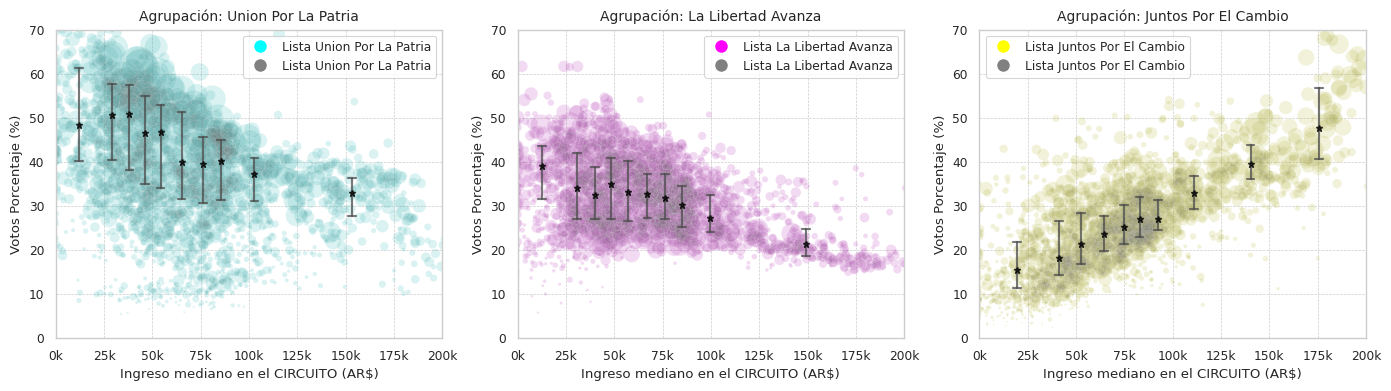

In [144]:


# Create a new figure with 1 row and 3 columns for the subplots
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

for ax, agrupacion in zip(axs, main_listas['agrupacion_nombre_'].unique()):
    if agrupacion in colors_dict:
        rows_for_agrupacion = main_listas[main_listas['agrupacion_nombre_'] == agrupacion]
        
        legend_elements = []  # To collect legend handles and labels
        for idx, row in enumerate(rows_for_agrupacion.iterrows()):
            _, row = row
            should_shade = idx == 1
            # plot_weighted_box(fig, ax, info, row['votos_tipo'], agrupacion, row['agrupacion_nombre'], ingreso_medio, bins=np.arange(10000, 200000, 20000))
            plot_weighted_box(fig, ax, info, row['votos_tipo'], agrupacion, row['agrupacion_nombre'], ingreso_medio, bins='weighted', nweighted=10)
            
            scatter_plot = plot_scatter(fig, ax, info, row['votos_tipo'], agrupacion, row['agrupacion_nombre'], ingreso_medio, colors_dict, shade=should_shade, alpha=0.1)
            color = 'gray' if should_shade else colors_dict.get(agrupacion, 'black')
            legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f"Lista {row['agrupacion_nombre']}"))

        # Add legend to ax after all plots are drawn
        ax.legend(handles=legend_elements)

# Adjust layout
plt.tight_layout()
# create if not exists
# import 
from pathlib import Path
Path('images').mkdir(parents=True, exist_ok=True)
# Save figure
plt.savefig('images/votos_vs_ingresosPASO23.jpg')
plt.show()


In [155]:
circuitos_list = ingreso_medio.loc[(ingreso_medio.ingresos < 100000)].circuito_id.unique()

In [166]:
antis = info.loc[(info.agrupacion_nombre == 'Union Por La Patria') & (info.votos_porcentaje < .16) & (info.circuito_id.isin(circuitos_list))].groupby('distrito_nombre')['votos_cantidad'].sum().sort_values()
antis

distrito_nombre
Buenos Aires                          291
San Luis                              435
San Juan                              460
Entre Ríos                           1185
Tucumán                              1352
Santa Fe                             1513
Corrientes                           2151
Mendoza                              3577
Ciudad Autónoma De Buenos Aires      8138
Córdoba                            183491
Name: votos_cantidad, dtype: int64

In [165]:
antis.sum()

191766

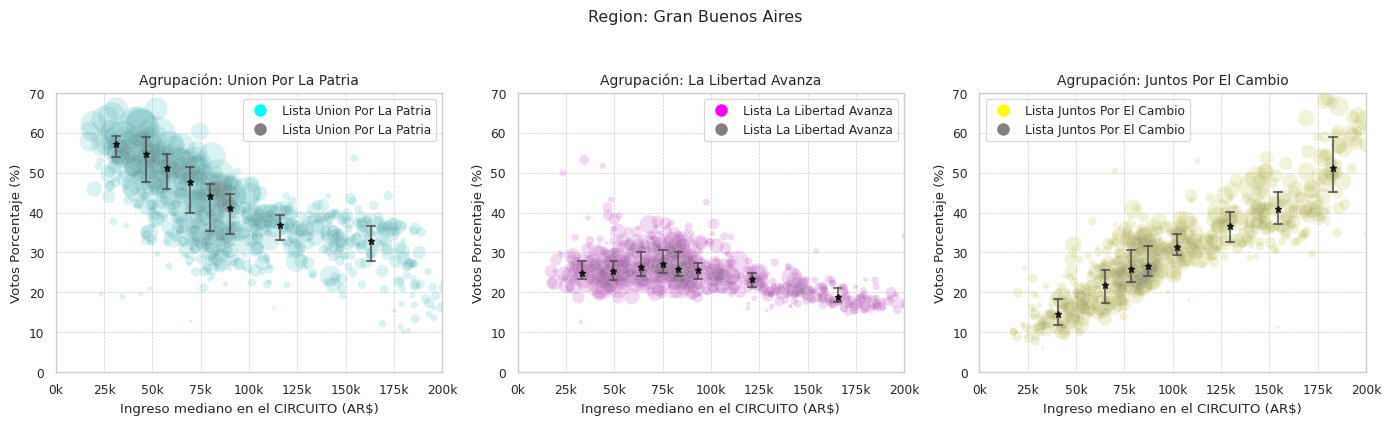

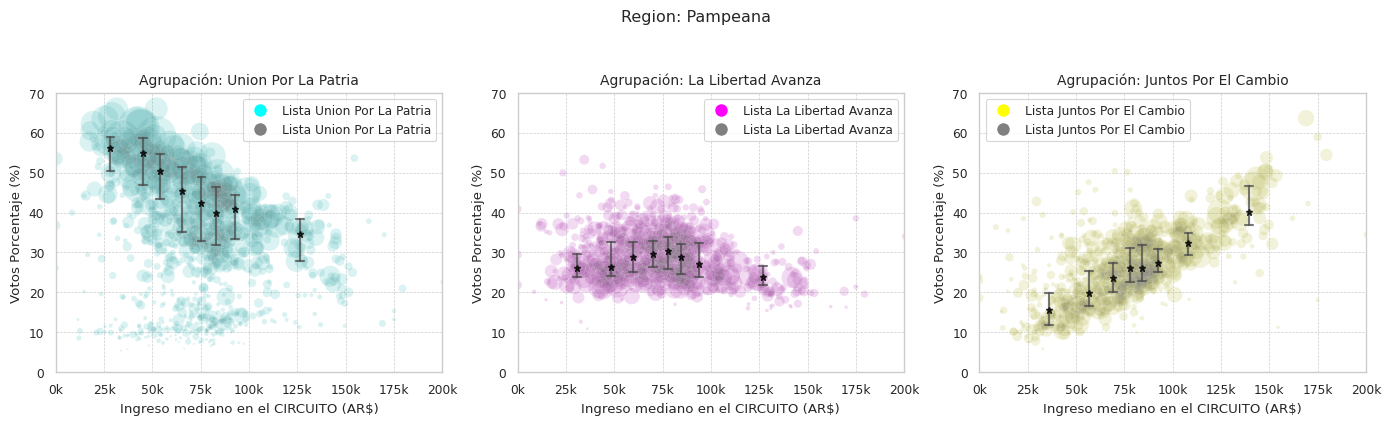

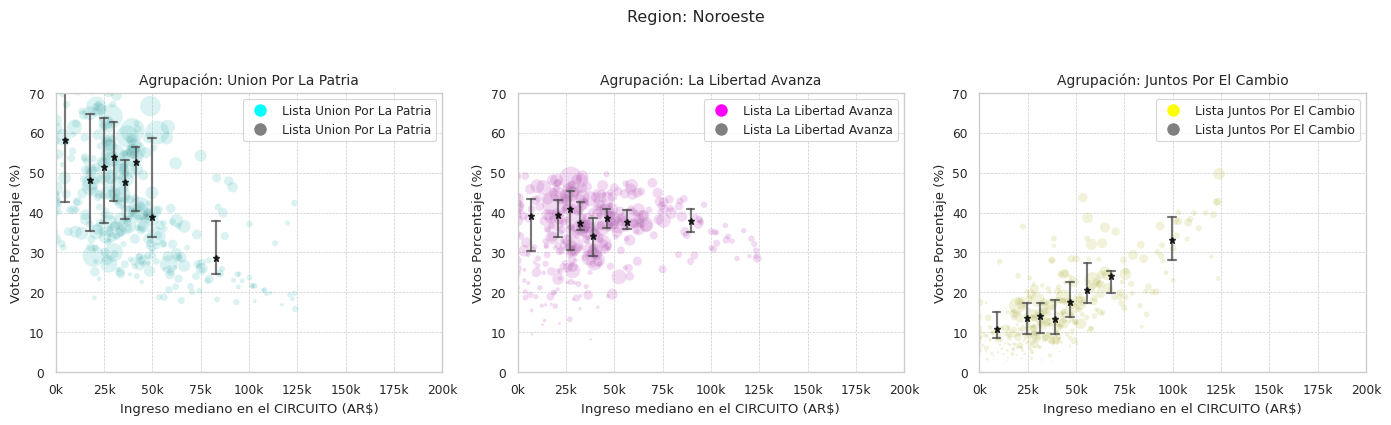

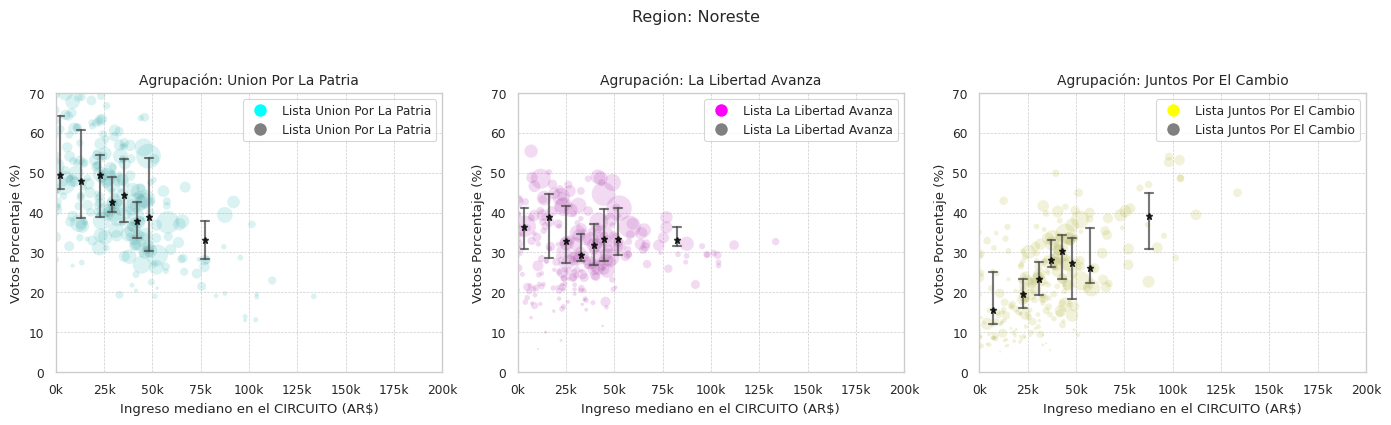

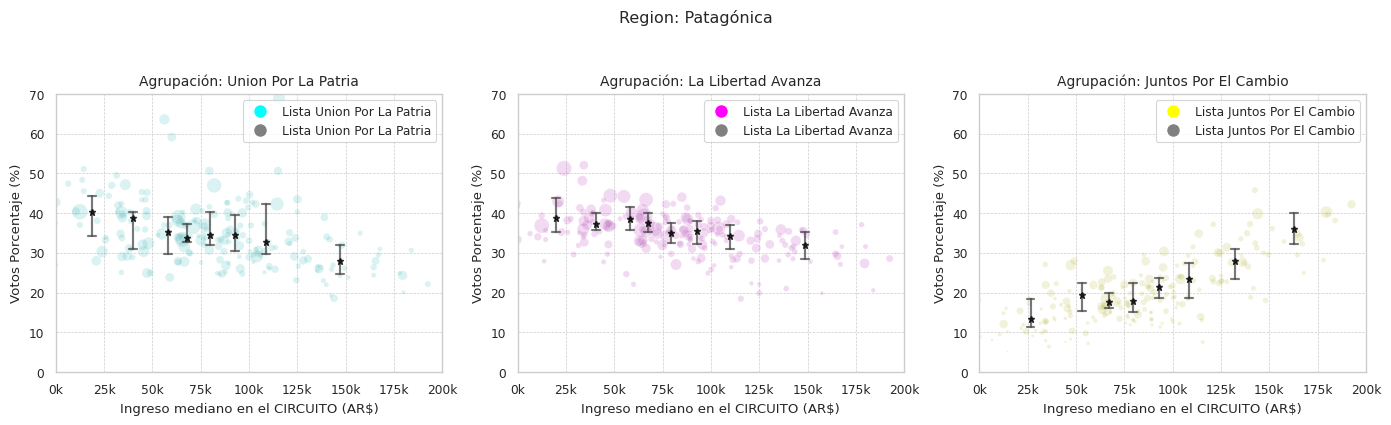

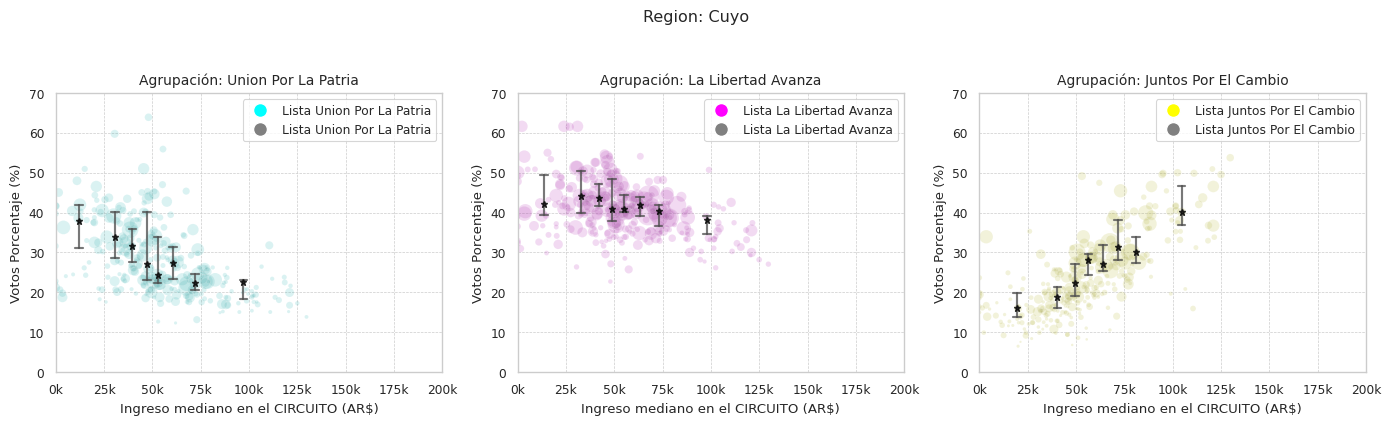

In [145]:
# Extract unique regions
unique_regions = seccion_region.drop_duplicates(subset=['Region'])['Region']

# Loop over each unique region
for region in unique_regions:
    
    # Filter the data for the current region
    region_ids = seccion_region[seccion_region['Region'] == region]['distrito_id'].unique()
    filtered_info = info[info['distrito_id'].isin(region_ids)]

    # Create a new figure with 1 row and 3 columns for the subplots
    fig, axs = plt.subplots(1, 3, figsize=(14, 4))
    
    # Loop over each agrupacion within the filtered data
    for ax, agrupacion in zip(axs, main_listas['agrupacion_nombre_'].unique()):
        if agrupacion in colors_dict:
            rows_for_agrupacion = main_listas[main_listas['agrupacion_nombre_'] == agrupacion]
            
            legend_elements = []  # To collect legend handles and labels
            for idx, row in enumerate(rows_for_agrupacion.iterrows()):
                _, row = row
                should_shade = idx == 1
                plot_weighted_box(fig, ax, filtered_info, row['votos_tipo'], agrupacion, row['agrupacion_nombre'], ingreso_medio, bins='weighted', nweighted = 8)
                
                scatter_plot = plot_scatter(fig, ax, filtered_info, row['votos_tipo'], agrupacion, row['agrupacion_nombre'], ingreso_medio, colors_dict, shade=should_shade, alpha=0.1)
                color = 'gray' if should_shade else colors_dict.get(agrupacion, 'black')
                legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f"Lista {row['agrupacion_nombre']}"))

            # Add legend to ax after all plots are drawn
            ax.legend(handles=legend_elements)
    
 # Set super title for the region
    plt.suptitle(f"Region: {region}", y=1.05)  # You might need to adjust the 'y' value for the best positioning
    
    # Adjust layout
    plt.tight_layout()
    
    # Save each region's figure separately
    plt.savefig(f'images/votos_vs_ingresosPASO23_region_{region}.jpg', bbox_inches='tight')  # Adding bbox_inches ensures everything is captured
    plt.show()


## Mirar data de Region

In [ ]:
# seccion_region.loc[seccion_region.Region == 'Pampeana'].sample(30)

seccion_region

In [ ]:
# info.loc[info.distrito_id == 21][['distrito_id', 'seccion_id', 'distrito_nombre', 'NOMDPTO']].drop_duplicates()

In [ ]:

# agrupacion_nombre_ = 'La Libertad Avanza'

filtered_info = info.loc[(info.votos_tipo == 'POSITIVO')][['distrito_id', 'distrito_nombre', 'seccion_nombre', 'circuito_id', 'agrupacion_nombre_', 'votos_cantidad', 'votos_porcentaje']]
filtered_info = filtered_info.merge(ingreso_medio)
    # info_plot_sorted = info_plot.sort_values(by='votos_porcentaje', ascending=True).reset_index(drop=True)
    # info_plot_sorted['x_bins'] = pd.cut(info_plot_sorted.ingresos, bins=bins, labels=False)


# Extract the desired columns
result_data = filtered_info[['distrito_id', 'distrito_nombre', 'seccion_id', 'seccion_nombre', 'circuito_id', 'agrupacion_nombre_',
                             'ingresos', 'votos_porcentaje', 'votos_cantidad']]


In [ ]:
table = result_data.groupby(['distrito_id', 'seccion_id', 'circuito_id', 'agrupacion_nombre_'])[['ingresos', 'votos_porcentaje', 'votos_cantidad']].first()#.reset_index()
table = table.unstack(-1)
table = table.loc[(table[('votos_porcentaje', 'La Libertad Avanza')] > .35)]
table = table.loc[(table[('ingresos', 'La Libertad Avanza')] > 50000) & (table[('ingresos', 'La Libertad Avanza')] < 100000)]
sorted = table.sort_values(by = ('votos_cantidad', 'La Libertad Avanza'), ascending = False) 
principal = sorted.iloc[:len(sorted)//2].sort_index()
# x = sorted[('votos_cantidad', 'La Libertad Avanza')]
# (x.cumsum()/x.sum()).plot()
data = principal.stack().reset_index()

data = data.merge(info[['distrito_id', 'seccion_id', 'distrito_nombre', 'seccion_nombre', 'Region']].drop_duplicates(), on=['distrito_id', 'seccion_id'], how='left')



In [ ]:
# Group by seccion, circuito, and agrupacion
grouped_data = data.groupby(['distrito_nombre', 'seccion_nombre', 'circuito_id', 'agrupacion_nombre_']).agg({
    'votos_cantidad': 'sum',
    'votos_porcentaje': 'mean'
}).reset_index()

# Pivot the table for better readability
pivot_data = grouped_data.pivot_table(index=['distrito_nombre', 'seccion_nombre', 'circuito_id'], 
                                      columns='agrupacion_nombre_', 
                                      values=['votos_cantidad', 'votos_porcentaje']).reset_index()

# # Extract and display summaries for each seccion
# summary_tables = {}
# unique_secciones = data['seccion_nombre'].unique()

# for seccion in unique_secciones:
#     summary_tables[seccion] = pivot_data[pivot_data['seccion_nombre'] == seccion]


In [ ]:
secciones = filtered_info.groupby(['distrito_nombre', 'seccion_nombre'])['votos_cantidad'].sum().sort_values(ascending = False).reset_index()
secciones

import warnings
# # You have already created the grouped and pivot data.
# You have the grouped data as a DataFrame named secciones.

# Loop over the largest places
for idx, row in secciones.head(len(secciones)//2).head().iterrows():
    distrito = row['distrito_nombre']
    seccion = row['seccion_nombre']
    
    # Extract data for the current distrito and seccion
    summary_table = pivot_data[(pivot_data['distrito_nombre'] == distrito) & (pivot_data['seccion_nombre'] == seccion)]
    
    # Check if the summary table is not empty
    if len(summary_table) > 0:
        
        # For simplification, I'm removing the distrito and seccion columns, as they will be displayed in the title
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            summary_table = summary_table.drop(columns=['distrito_nombre', 'seccion_nombre'])

        # Multiply percentages by 100 and round to 1 decimal
        for col in summary_table.columns:
            if 'votos_porcentaje' in col:
                summary_table[col] = (summary_table[col] * 100).round(1)
        
        # Display the table
        print(f"Distrito: {distrito}, Seccion: {seccion}")
        display(summary_table.reset_index(drop = True))
        print("\n" + "="*100 + "\n")  # To separate the tables


Distrito: Córdoba, Seccion: Capital


circuito_id                                 votos_cantidad  \
agrupacion_nombre_             Frente De Izquierda Y De Trabajadores - Unidad   
0                       000005                                            115   
1                       000013                                             46   
2                       00005C                                            166   
3                       00008C                                             58   
4                       00010E                                            105   
5                       00010J                                            105   
6                       00013F                                             62   
7                       00013G                                            119   
8                       00013H                                            110   
9                       00013N                                             79   
10                      00014E                                             56   

                                                                  \
agrupacion_nombre_ Hacemos Por Nuestro Pais Juntos Por El Cambio   
0                                      2703                 1719   
1                                      1783                 1163   
2                                      3937                 2332   
3                                      1793                 1007   
4                                      3624                 1352   
5                                      2930                 1256   
6                                      1712                 1073   
7                                      5434                 1807   
8                                      4149                 1583   
9                                      1548                  987   
10                                     1449                  787   

                                                           \
agrupacion_nombre_ La Libertad Avanza Union Por La Patria   
0                                3225                 426   
1                                2178                 318   
2                                4556                 522   
3                                2180                 252   
4                                3678                 401   
5                                3336                 368   
6                                2101                 262   
7                                5158                 547   
8                                4235                 510   
9                                1900                 262   
10                               1628                 184   

                                                 votos_porcentaje  \
agrupacion_nombre_ Frente De Izquierda Y De Trabajadores - Unidad   
0                                                             1.3   
1                                                             0.8   
2                                                             1.3   
3                                                             1.0   
4                                                             1.0   
5                                                             1.2   
6                                                             1.1   
7                                                             0.8   
8                                                             0.9   
9                                                             1.5   
10                                                            1.2   

                                                                  \
agrupacion_nombre_ Hacemos Por Nuestro Pais Juntos Por El Cambio   
0                                      29.5                 18.7   
1                                      29.4                 19.2   
2                                      31.1                 18.4   
3                                      31.0     



Distrito: Tucumán, Seccion: Capital


circuito_id                                 votos_cantidad  \
agrupacion_nombre_             Frente De Izquierda Y De Trabajadores - Unidad   
0                       000009                                            128   
1                       000012                                            152   
2                       000013                                            175   
3                       000014                                            183   
4                       000016                                            162   
5                       000017                                            159   
6                       000018                                            169   
7                       00008A                                            100   
8                       00009A                                             92   
9                       00012A                                             82   
10                      00016A                                            149   
11                      00018D                                             45   

                                                                  \
agrupacion_nombre_ Hacemos Por Nuestro Pais Juntos Por El Cambio   
0                                        84                 1135   
1                                        96                 1753   
2                                       100                 1293   
3                                       156                 1898   
4                                       118                 2228   
5                                       186                 2096   
6                                       158                 1872   
7                                        73                 1005   
8                                        79                  918   
9                                        73                  773   
10                                      121                 1640   
11                                       46                  370   

                                                           \
agrupacion_nombre_ La Libertad Avanza Union Por La Patria   
0                                3075                1492   
1                                2817                1086   
2                                2642                1351   
3                                4818                2817   
4                                3455                1319   
5                                4048                1797   
6                                4616                1864   
7                                1985                 761   
8                                2787                1546   
9                                2392                1258   
10                               3137                1395   
11                               1636                 837   

                                                 votos_porcentaje  \
agrupacion_nombre_ Frente De Izquierda Y De Trabajadores - Unidad   
0                                                             1.6   
1                                                             2.0   
2                                                             2.4   
3                                                             1.4   
4                                                             1.7   
5                                                             1.4   
6                                                             1.5   
7                                                             1.9   
8                                                             1.3   
9                                                             1.4   
10                                                            1.7   
11                                                            1.2   

                                                                  \
agrupacion_nombre_ Hacemos Por Nuestro Pa

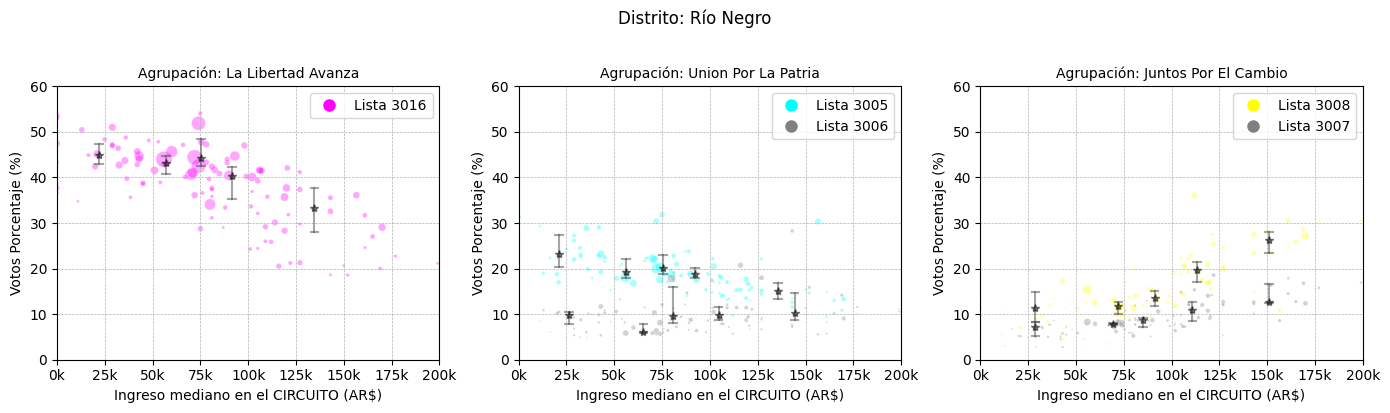

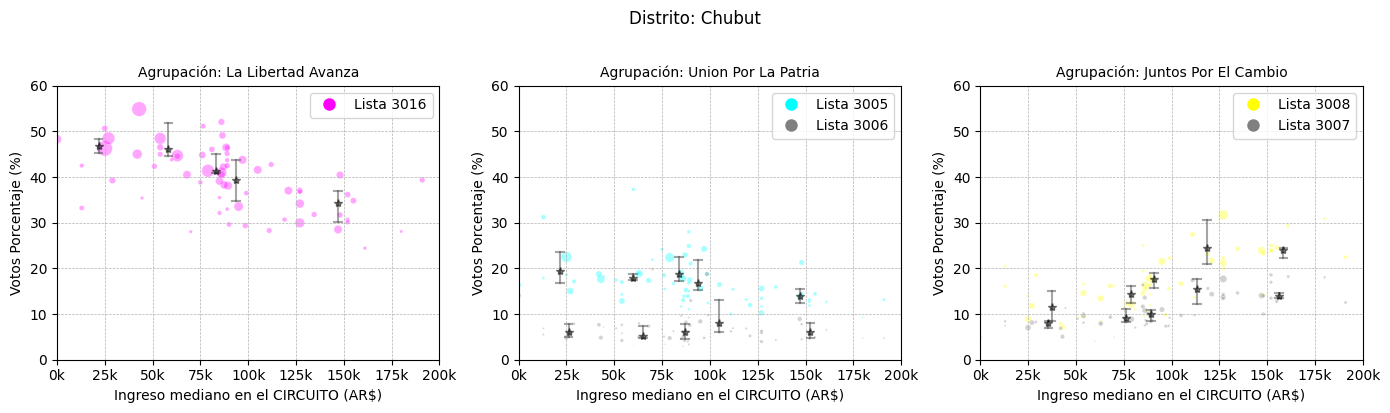

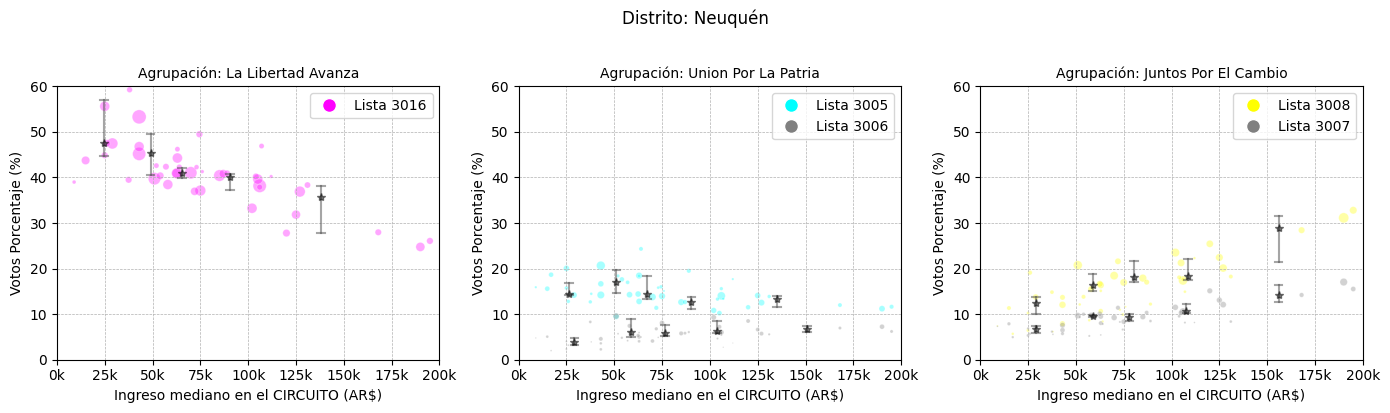

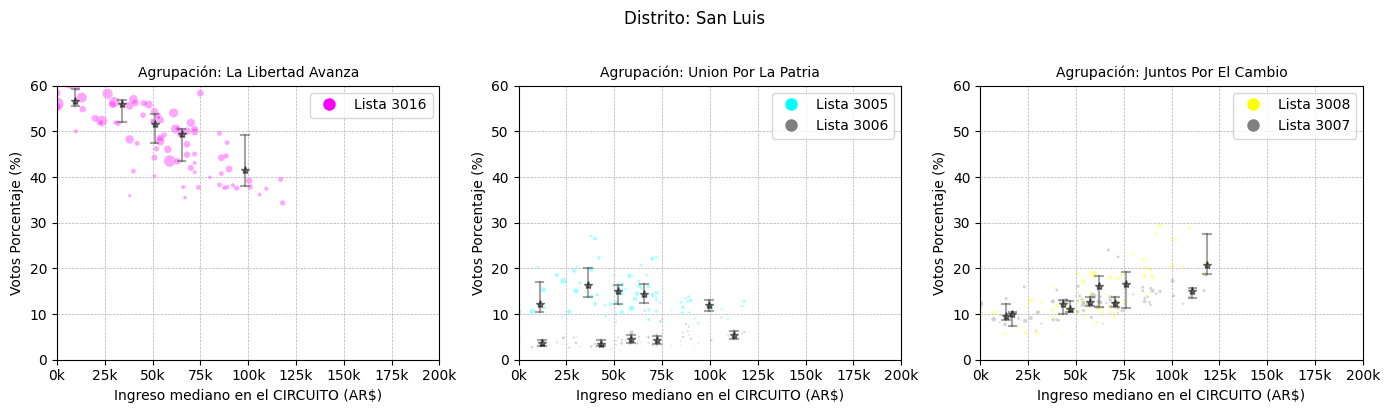

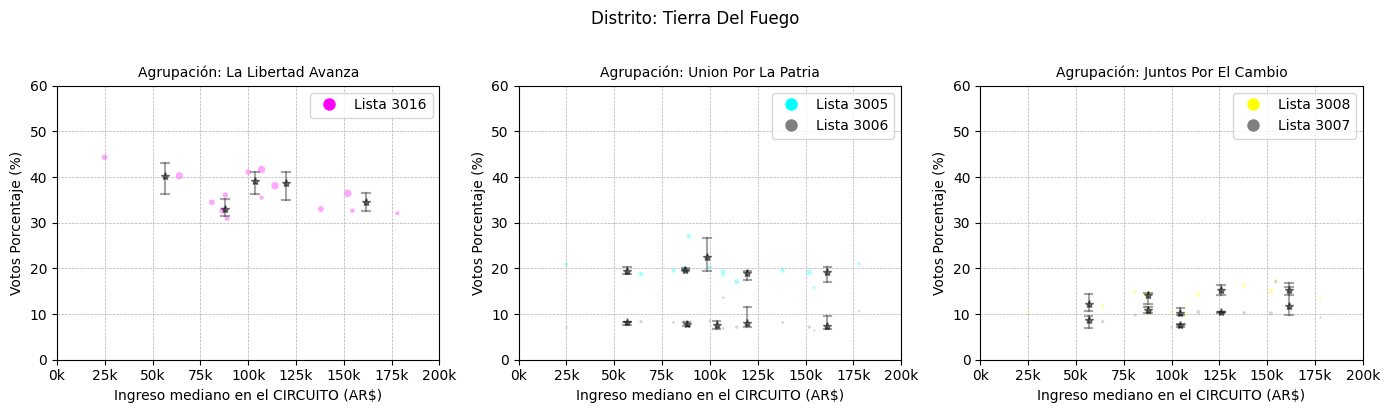

In [ ]:
# Extract unique distrito_id and corresponding distrito_nombre pairs
unique_distritos = info.drop_duplicates(subset=['distrito_id', 'distrito_nombre'])[['distrito_id', 'distrito_nombre']].tail()

# Loop over each unique distrito_id and its corresponding distrito_nombre
for _, distrito_row in unique_distritos.iterrows():
    distrito_id = distrito_row['distrito_id']
    distrito_nombre = distrito_row['distrito_nombre']

    # Filter the data for the current distrito_id
    filtered_info = info[info['distrito_id'] == distrito_id]

    # Create a new figure with 1 row and 3 columns for the subplots
    fig, axs = plt.subplots(1, 3, figsize=(14, 4))
    
    # Loop over each agrupacion within the filtered data
    for ax, agrupacion in zip(axs, main_listas['agrupacion_nombre_'].unique()):
        if agrupacion in colors_dict:
            rows_for_agrupacion = main_listas[main_listas['agrupacion_nombre_'] == agrupacion]
            
            legend_elements = []  # To collect legend handles and labels
            for idx, row in enumerate(rows_for_agrupacion.iterrows()):
                _, row = row
                should_shade = idx == 1
                plot_weighted_box(fig, ax, filtered_info, row['votos_tipo'], agrupacion, row['agrupacion_nombre'], ingreso_medio, bins='weighted', nweighted=5)
                
                scatter_plot = plot_scatter(fig, ax, filtered_info, row['votos_tipo'], agrupacion, row['agrupacion_nombre'], ingreso_medio, colors_dict, shade=should_shade, alpha = .35)
                color = 'gray' if should_shade else colors_dict.get(agrupacion, 'black')
                legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f"Lista {row['agrupacion_nombre']}"))

            # Add legend to ax after all plots are drawn
            ax.legend(handles=legend_elements)


     # Set super title for the region
    plt.suptitle(f"Distrito: {distrito_nombre}", y=1.02)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save each region's figure separately
    plt.savefig(f'images/votos_vs_ingresosPASO23_distrito_{distrito_nombre}.jpg', bbox_inches='tight')  # Adding bbox_inches ensures everything is captured)
    plt.show()


In [ ]:
# for index, row in main_listas.iterrows():
#     # Check if the agrupacion_nombre_ has a color defined in colors_dict
#     # if row['agrupacion_nombre_'] in colors_dict:
#     # Create a new figure for each iteration
#     fig, axs = plt.subplots(1, 1, figsize=(6, 5))

#     plot_scatter(fig, axs, info, row['votos_tipo'], row['agrupacion_nombre_'], row['agrupacion_nombre'], ingreso_medio, colors_dict)
#     plot_weighted_box(fig, axs, info, row['votos_tipo'], row['agrupacion_nombre_'], row['agrupacion_nombre'], ingreso_medio)

#     plt.tight_layout()
#     plt.show()

In [ ]:
info

,votos_tipo,agrupacion_nombre_,lista_numero,distrito_id,seccion_id,circuito_id,eleccion_id,cargo_id,votos_cantidad,año,eleccion_tipo,recuento_tipo,padron_tipo,eleccion_tag,cargo_nombre,cargo_tag,votos_porcentaje
0,POSITIVO,La Libertad Avanza,3016,2,77,00652A,17,1,22969,2023,PASO,PROVISORIO,NORMAL,PASO23n,Presidente,PR,0.281469
1,POSITIVO,La Libertad Avanza,3016,2,61,00635B,17,1,17119,2023,PASO,PROVISORIO,NORMAL,PASO23n,Presidente,PR,0.254014
2,POSITIVO,La Libertad Avanza,3016,2,80,000665,17,1,17272,2023,PASO,PROVISORIO,NORMAL,PASO23n,Presidente,PR,0.251885
3,POSITIVO,La Libertad Avanza,3016,2,38,000302,17,1,17723,2023,PASO,PROVISORIO,NORMAL,PASO23n,Presidente,PR,0.267267
4,POSITIVO,La Libertad Avanza,3016,2,61,000635,17,1,15525,2023,PASO,PROVISORIO,NORMAL,PASO23n,Presidente,PR,0.256662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,POSITIVO,Frente De Izquierda Y De Trabajadores - Unidad,3009,2,107,000907,17,1,13,2023,PASO,PROVISORIO,NORMAL,PASO23n,Presidente,PR,0.014525
23996,POSITIVO,Frente De Izquierda Y De Trabajadores - Unidad,3009,22,12,000103,17,1,5,2023,PASO,PROVISORIO,NORMAL,PASO23n,Presidente,PR,0.005133
23997,POSITIVO,Frente De Izquierda Y De Trabajadores - Unidad,3009,7,14,00084A,17,1,3,2023,PASO,PROVISORIO,NORMAL,PASO23n,Presidente,PR,0.003122
23998,POSITIVO,Frente De Izquierda Y De Trabajadores - Unidad,3009,8,9,000164,17,1,4,2023,PASO,PROVISORIO,NORMAL,PASO23n,Presidente,PR,0.004206


In [ ]:
xx

In [ ]:
import pandas as pd

import math

def harmonize_agrupacion_id(agrupacion_id):
    if pd.isna(agrupacion_id):
        return "000000"
    else:
        try:
            # Attempt to convert string to float and then to integer
            return str(int(float(agrupacion_id))).zfill(6)
        except ValueError:
            # If conversion fails, return original string value
            return agrupacion_id

In [ ]:
# Read the CSV file into a DataFrame
df = pd.read_csv('./../datos/BD/votos_eleccion_17_table.csv') 


# Filter the DataFrame using loc and the condition (for example, where 'cargo_id' is 1 or 3)
df = df.loc[df['cargo_id'].isin([1, 3])]
data = df
data['agrupacion_id'] = data['agrupacion_id'].apply(harmonize_agrupacion_id)

/tmp/ipykernel_186561/1967422595.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./../datos/BD/votos_eleccion_17_table.csv')


In [ ]:
cargo = pd.read_csv('./../datos/BD/cargo_table.csv')

agrup_lista = pd.read_csv('./../datos/BD/agrupacion_lista_table.csv')
agrup_lista['agrupacion_id'] = agrup_lista['agrupacion_id'].apply(harmonize_agrupacion_id)
agrup_lista['agrupacion_nombre'] = agrup_lista['agrupacion_nombre'].apply(harmonize_agrupacion_id)
agrup_lista


simil_nombre = agrup_lista.groupby(['eleccion_id', 'distrito_id', 'distrito_nombre', 'agrupacion_id']).agrupacion_nombre.first().reset_index()

merged_data = data.merge(simil_nombre)

In [ ]:

merged_data['agrupacion_nombre'] = merged_data['agrupacion_nombre'].replace('CAMBIEMOS BUENOS AIRES', 'CAMBIEMOS')
merged_data['agrupacion_nombre'] = merged_data['agrupacion_nombre'].replace('JUNTOS', 'JUNTOS POR EL CAMBIO', regex=False)
merged_data['agrupacion_nombre'] = merged_data['agrupacion_nombre'].str.title()




In [ ]:
out = merged_data.groupby(['eleccion_id', 'cargo_id', 'agrupacion_nombre', 'agrupacion_nombre', 'votos_tipo'])[['votos_cantidad']].sum().reset_index()
out


,eleccion_id,cargo_id,agrupacion_nombre,lista_numero,votos_tipo,votos_cantidad
0,17,1,Frente De Izquierda Y De Trabajadores - Unidad,3009,POSITIVO,442085
1,17,1,Frente De Izquierda Y De Trabajadores - Unidad,3010,POSITIVO,186808
2,17,1,Frente Liber.Ar,3002,POSITIVO,8281
3,17,1,Frente Liber.Ar,3003,POSITIVO,13109
4,17,1,Frente Liber.Ar,3004,POSITIVO,5572
...,...,...,...,...,...,...
230,17,3,Union Por La Patria,3325,POSITIVO,295149
231,17,3,Union Por San Luis,3125,POSITIVO,46949
232,17,3,Unite Por La Libertad Y La Dignidad,3121,POSITIVO,1157
233,17,3,Unite Por La Libertad Y La Dignidad,3142,POSITIVO,961


In [ ]:
n = 6
main = out.groupby(['eleccion_id', 'cargo_id', 'votos_tipo']).apply(lambda x: x.nlargest(n, 'votos_cantidad')).reset_index(drop=True).rename(columns={'votos_cantidad': 'votos_nacional'})
main


,eleccion_id,cargo_id,agrupacion_nombre,lista_numero,votos_tipo,votos_nacional
0,17,1,La Libertad Avanza,3016,POSITIVO,7116352
1,17,1,Union Por La Patria,3005,POSITIVO,5070104
2,17,1,Juntos Por El Cambio,3008,POSITIVO,4022466
3,17,1,Juntos Por El Cambio,3007,POSITIVO,2675563
4,17,1,Union Por La Patria,3006,POSITIVO,1390585
5,17,1,Hacemos Por Nuestro Pais,3001,POSITIVO,907437
6,17,3,Union Por La Patria,3005,POSITIVO,3797584
7,17,3,La Libertad Avanza,3016,POSITIVO,2968100
8,17,3,Juntos Por El Cambio,3008,POSITIVO,2461554
9,17,3,Juntos Por El Cambio,3007,POSITIVO,1958899


In [ ]:
data_copy = data.copy()

In [ ]:
data_copy['agrupacion_nombre'] = data_copy['agrupacion_nombre'].replace('CAMBIEMOS BUENOS AIRES', 'CAMBIEMOS')
data_copy['agrupacion_nombre'] = data_copy['agrupacion_nombre'].replace('JUNTOS', 'JUNTOS POR EL CAMBIO')
data_copy['agrupacion_nombre'] = data_copy['agrupacion_nombre'].str.title()



data_copy = data_copy.merge(main, how = 'left')

## Limpiar

data_copy['agrupacion_nombre'] = data_copy['agrupacion_nombre'].str.title().str.strip()

data_copy['agrupacion_nombre_'] = data_copy['agrupacion_nombre'].mask(data_copy['votos_nacional'].isnull()).fillna('Resto')

data_aggregated = data_copy.groupby(['distrito_id', 'distrito_nombre', 'seccion_id', 'circuito_id', 'mesa_id', 'cargo_id', 'agrupacion_nombre_', 'votos_tipo', 'eleccion_id'])['votos_cantidad'].sum()
data_aggregated = data_aggregated.reset_index()

In [ ]:
## Seccion_id no es necesario, alcanza con provincia-circuito. Pero lo agregamos porque a traves de los circuitos se relaciona el seccion_id con el id de deptos en IGN.
data_circ = data_aggregated.groupby(['eleccion_id', 'cargo_id', 'agrupacion_nombre_', 'votos_tipo', 'distrito_id', 'distrito_nombre', 'seccion_id', 'circuito_id'])[['votos_cantidad']].sum()
# data_circ.to_csv('./../datos/out/votos_agrup_circ.csv')
data_circ.groupby('cargo_id').votos_cantidad.sum()

cargo_id
1    24016776
3    23502142
Name: votos_cantidad, dtype: int64

In [ ]:
claves_dptos = pd.read_csv('./../datos/BD/claves_dptos_ref.csv')
claves_dptos = claves_dptos.loc[~claves_dptos.codprov.isna()].astype({'codprov': 'Int64', 'coddepto' : 'Int64', 'IN1' : 'Int64'})
claves_dptos['codprov'] = claves_dptos['codprov'].astype(str).str.zfill(2)
claves_dptos['coddepto'] = claves_dptos['coddepto'].astype(str).str.zfill(3)
claves_dptos['IN1'] = claves_dptos['IN1'].astype(str).str.zfill(5)
claves_dptos.loc[(claves_dptos.seccion_nombre == 'La Plata'), 'IN1'] = '06441'
claves_dptos.head()

prov_ids = claves_dptos.copy()
prov_ids['in1_prov'] = prov_ids['IN1'].astype(str).str[:2]
prov_ids = prov_ids[['distrito_id', 'distrito_nombre', 'in1_prov']].drop_duplicates().reset_index(drop=True)

# prov_ids = pd.read_csv('./../datos/info/radio_ref.csv')[['PROV_REF_ID', 'IDPROV']].drop_duplicates().rename(columns = {'IDPROV': 'in1_prov', 'PROV_REF_ID': 'distrito_id'}).reset_index(drop = True)
# prov_ids['in1_prov'] = prov_ids['in1_prov'].astype(str).str.zfill(2)
# prov_ids.head()

eleccion_tags = pd.read_csv('./../datos/BD/eleccion_tags.csv')


In [ ]:
# data_circ = pd.read_csv('./../datos/out/votos_circ.csv').merge(prov_ids)
data_circ = pd.read_csv('./../datos/out/votos_agrup_circ.csv').merge(prov_ids)
# data_circ['agrupacion_nombre_'] = data_circ['agrupacion_nombre_'].fillna('NO POSITIVOS')

# Guardar ref provs - dptos - circs
dist_secc_circ = data_circ.copy() # save for later

# data_circ
data_circ = data_circ.merge(eleccion_tags).merge(cargo)


# Group by 'eleccion_tag', 'cargo_tag', and 'in1_prov', and calculate the sum of 'votos_cantidad', divide for PCT
sum_votes = data_circ.groupby(['eleccion_tag', 'cargo_tag', 'in1_prov', 'votos_tipo', 'circuito_id'])['votos_cantidad'].transform('sum')
data_circ['votos_porcentaje'] = data_circ['votos_cantidad'] / sum_votes


data_circ = data_circ.set_index(['distrito_id', 'distrito_nombre', 'circuito_id', 'eleccion_tag', 'cargo_tag', 'agrupacion_nombre_', 'votos_tipo'])


data_circ_table_cnt = data_circ['votos_cantidad'].unstack(['eleccion_tag', 'cargo_tag', 'votos_tipo', 'agrupacion_nombre_'])
data_circ_table_pct = data_circ['votos_porcentaje'].unstack(['eleccion_tag', 'cargo_tag', 'votos_tipo', 'agrupacion_nombre_'])


In [ ]:

data_circ_geoms_cnt.to_file('./../datos/geojson/votos_cnt_circ.geojson', driver='GeoJSON') # Save the GeoDataFrame to GeoJSON
data_circ_geoms_pct.to_file('./../datos/geojson/votos_pct_circ.geojson', driver='GeoJSON') # Save the GeoDataFrame to GeoJSON


data_circ_geoms_cnt.to_file('./../datos/geojson/votos_cnt_circ.geojson', driver='GeoJSON') # Save the GeoDataFrame to GeoJSON
data_circ_geoms_pct.to_file('./../datos/geojson/votos_pct_circ.geojson', driver='GeoJSON') # Save the GeoDataFrame to GeoJSON


data_circ_geoms_cnt.to_file('./../datos/geojson/votos_cnt_circ.geojson', driver='GeoJSON') # Save the GeoDataFrame to GeoJSON
data_circ_geoms_pct.to_file('./../datos/geojson/votos_pct_circ.geojson', driver='GeoJSON') # Save the GeoDataFrame to GeoJSON